In [1]:
import pandas as pd

# Lead Table - DIM
df_leads = pd.read_csv(
    "DTC Leads Data Set - dim lead(Sheet1).csv",
    parse_dates=[
        'Lead Created (ET) Time',
        'Last Contact Attempt (ET) Time'
    ],
)

# Call Activity Table - FACT

df_calls = pd.read_csv(
    "Call Activity Data Set - Dials(Call Activity Data Set 2026-02-).csv",
    parse_dates=[
        'Lead Created (ET) Time',
        'Activity (ET) Time',
        'First Contact (ET) Time'
    ]
)

# Shape
print("Leads shape:".ljust(18), df_leads.shape)
print("Calls shape:".ljust(18), df_calls.shape)

print("\nLEADS COLS")
print(df_leads.dtypes)

print("\nCALL ACTIVITY COLS")
print(df_calls.dtypes)

Leads shape:       (35170, 19)
Calls shape:       (382454, 23)

LEADS COLS
Lead ID                                          str
Last Contact Attempt (ET) Time        datetime64[us]
Utm Source                                       str
Utm Medium                                       str
Lead Source                                      str
Lead Channel Segment                             str
Borrower Requested Loan Type                     str
Current Lead Status                              str
Lead Created (ET) Date                           str
Lead Created (ET) Time                datetime64[us]
Gross Leads                                    int64
Number of Called Leads                         int64
Number of Contacted Leads                      int64
Number of Opportunities                        int64
Number of File Started Leads                   int64
Number of Entered Processing Leads             int64
Number of Locked Loan Leads                    int64
Number of Pre-Approval L

In [2]:
# Join check

print("Lead table join key sample:")
print(df_leads['Lead ID'].head(3))
print(df_leads['Lead ID'].dtype)
print()

print("Call activity table join key sample:")
print(df_calls['Lead ID'].head(3))
print(df_calls['Lead ID'].dtype)
print()

print("Any missing values in join key?")
print("leads  :", df_leads['Lead ID'].isna().sum())
print("calls  :", df_calls['Lead ID'].isna().sum())

Lead table join key sample:
0    00QPh00000iEOItMAO
1    00QPh00000evzVxMAI
2    00QPh00000cZP7KMAW
Name: Lead ID, dtype: str
str

Call activity table join key sample:
0    00QPh00000kH72cMAC
1    00QPh00000kH72cMAC
2    00QPh00000kH72cMAC
Name: Lead ID, dtype: str
str

Any missing values in join key?
leads  : 1
calls  : 0


In [3]:
# PRE-FILTER: Leads that haven't been called due to business requirement conditions

# 1. How many leads have NULL last contact attempt?
null_last_attempt = df_leads['Last Contact Attempt (ET) Time'].isna().sum()
total_leads = len(df_leads)

print(f"Number of leads with NO contact attempt: {null_last_attempt:,}")
print(f" == {null_last_attempt / total_leads:.1%} of all Leads\n")

# 2. Quick distribution of called vs not called
print("Breakdown:")
print(df_leads['Last Contact Attempt (ET) Time'].notna().value_counts(normalize=True).mul(100).round(1).astype(str) + " %")
print()

# 3. Just to be extra sure...are there any empty strings instead of real NaT?
print("# of empty strings that look like missing?")
print((df_leads['Last Contact Attempt (ET) Time'].astype(str).str.strip() == '').sum())

Number of leads with NO contact attempt: 4,154
 == 11.8% of all Leads

Breakdown:
Last Contact Attempt (ET) Time
True     88.2 %
False    11.8 %
Name: proportion, dtype: str

# of empty strings that look like missing?
0


In [4]:
# Original size
total_leads = len(df_leads)
print(f"Original leads: {total_leads:,}")

# PRE-FILTER - keeping only leads that were actually called
df_leads_called = df_leads[
    df_leads['Last Contact Attempt (ET) Time'].notna()
].copy()

called_leads = len(df_leads_called)
print(f"Leads with at least one contact attempt: {called_leads:,}")
print(f" == {called_leads / total_leads:.1%} of total Leads\n")

# SANITY CHECK - last attempt time should now have 0 nulls
print("# of NULSS in Last Contact Attempt (ET) Time after filter:")
print(df_leads_called['Last Contact Attempt (ET) Time'].isna().sum())

Original leads: 35,170
Leads with at least one contact attempt: 31,016
 == 88.2% of total Leads

# of NULSS in Last Contact Attempt (ET) Time after filter:
0


In [5]:
# Do an INNER JOIN - clean standardized dataframe to work with

# Drop the redundant columns confirmed as identical
redundant_cols = ['Lead Created (ET) Time', 'Lead Created (ET) Date']

df_calls_clean = df_calls.drop(
    columns=[c for c in redundant_cols if c in df_calls.columns],
    errors='ignore'
)

print(f"Dropped {len(redundant_cols)} redundant columns from calls table")
print("Calls columns now:", df_calls_clean.columns.tolist()[:10], "...") 

# Standardize join key (just in case)
df_leads_called['Lead ID'] = df_leads_called['Lead ID'].astype(str).str.strip()
df_calls_clean['Lead ID']  = df_calls_clean['Lead ID'].astype(str).str.strip()

# INNER JOIN - only leads + calls that match on Lead ID

df_merged = pd.merge(
    df_leads_called,
    df_calls_clean,
    on='Lead ID',
    how='inner'
)

print("Shape:", df_merged.shape)
print("\nColumns and types:")
print(df_merged.dtypes)

Dropped 2 redundant columns from calls table
Calls columns now: ['Activity ID (Surrogate)', 'Lead ID', 'Activity (ET) Time', 'Activity (ET) Date', 'First Contact (ET) Time', 'Contacted? (Yes / No)', 'Direction', 'Incoming Lead? (Yes / No)', 'Is Live Transfer? (Yes / No)', 'Outcome'] ...


Shape: (382387, 39)

Columns and types:
Lead ID                                                 str
Last Contact Attempt (ET) Time               datetime64[us]
Utm Source                                              str
Utm Medium                                              str
Lead Source                                             str
Lead Channel Segment                                    str
Borrower Requested Loan Type                            str
Current Lead Status                                     str
Lead Created (ET) Date                                  str
Lead Created (ET) Time                       datetime64[us]
Gross Leads                                           int64
Number of Called Leads                                int64
Number of Contacted Leads                             int64
Number of Opportunities                               int64
Number of File Started Leads                          int64
Number of Entered Processing Leads                    int64


In [103]:
print("Activity (ET) Time range:")
print(df_merged['Activity (ET) Time'].min())
print(df_merged['Activity (ET) Time'].max())

print("\nFirst Contact (ET) Time range:")
print(df_merged['First Contact (ET) Time'].min())
print(df_merged['First Contact (ET) Time'].max())

Activity (ET) Time range:
2025-08-18 15:33:00
2026-02-13 12:15:00

First Contact (ET) Time range:
2025-08-19 15:58:00
2026-02-13 12:09:00


In [6]:
# 1. Make sure key date columns are datetime
# replace Lead Created (ET) time to First Contact 
df_merged['First Contact (ET) Time'] = pd.to_datetime(df_merged['First Contact (ET) Time'])
df_merged['Activity (ET) Time']     = pd.to_datetime(df_merged['Activity (ET) Time'])

# 2. Create relative day number (Day 1 = creation day)
df_merged['days_since_creation'] = (
    df_merged['Activity (ET) Time'].dt.date - 
    df_merged['First Contact (ET) Time'].dt.date
).apply(lambda x: x.days if pd.notnull(x) else pd.NA) + 1

# 3. Quick look at distribution of relative days
print("Relative day distribution (first 10 days):")
print(df_merged['days_since_creation'].value_counts().sort_index().head(10))

# 4. How many outbound vs inbound?
print("\nDirection breakdown:")
print(df_merged['Direction'].value_counts(dropna=False))

# 5. How many are Pool A attempts?
print("\nPool A attempts:")
print(df_merged['Is Pool A (Active SDR)? (Yes / No)'].value_counts(dropna=False))

Relative day distribution (first 10 days):
days_since_creation
-153    1
-145    1
-139    1
-138    1
-125    1
-124    1
-119    1
-117    1
-115    1
-111    1
Name: count, dtype: int64

Direction breakdown:
Direction
Outbound    363709
Inbound      18678
Name: count, dtype: int64

Pool A attempts:
Is Pool A (Active SDR)? (Yes / No)
Yes    291296
No      91091
Name: count, dtype: int64


In [7]:
df_merged.columns

Index(['Lead ID', 'Last Contact Attempt (ET) Time', 'Utm Source', 'Utm Medium',
       'Lead Source', 'Lead Channel Segment', 'Borrower Requested Loan Type',
       'Current Lead Status', 'Lead Created (ET) Date',
       'Lead Created (ET) Time', 'Gross Leads', 'Number of Called Leads',
       'Number of Contacted Leads', 'Number of Opportunities',
       'Number of File Started Leads', 'Number of Entered Processing Leads',
       'Number of Locked Loan Leads', 'Number of Pre-Approval Leads',
       'Number of Funded Loan Leads', 'Activity ID (Surrogate)',
       'Activity (ET) Time', 'Activity (ET) Date', 'First Contact (ET) Time',
       'Contacted? (Yes / No)', 'Direction', 'Incoming Lead? (Yes / No)',
       'Is Live Transfer? (Yes / No)', 'Outcome', 'Team Member ID',
       'Team Member Name', 'Team Member Role', 'Pool A Call Attempt Number',
       'Is Latest Pool A Dial Attempt? (Yes / No)',
       'Is Pool A (Active SDR)? (Yes / No)', 'Call Attempt Number',
       'Is Latest Di

In [8]:
# Filter to outbound Pool A attempts only

df_attempts = df_merged[
    (df_merged['Direction'] == 'Outbound') &
    # (df_merged['Is Pool A (Active SDR)? (Yes / No)'] == 'Yes') &
    (df_merged['days_since_creation'] >= 0)
].copy()

print("Rows after filtering to outbound Pool A attempts + no negative days since creation:", len(df_attempts))
print("Unique leads in this subset:", df_attempts['Lead ID'].nunique())

# Quick check on attempt numbers
print("\nPool A attempt number distribution (top 10 values):")
print(df_attempts['Pool A Call Attempt Number'].value_counts().sort_index().head(15))

# Confirm relative days are already calculated (from earlier)
print("\nDays since creation in this subset (first 10 values):")
print(df_attempts['days_since_creation'].value_counts().sort_index().head(10))

Rows after filtering to outbound Pool A attempts + no negative days since creation: 111246
Unique leads in this subset: 17104

Pool A attempt number distribution (top 10 values):
Pool A Call Attempt Number
1.0     10162
2.0      6562
3.0      5625
4.0      5263
5.0      4916
6.0      4530
7.0      4227
8.0      3995
9.0      3735
10.0     3566
11.0     3464
12.0     3359
13.0     3261
14.0     3105
15.0     3018
Name: count, dtype: int64

Days since creation in this subset (first 10 values):
days_since_creation
0     8811
1    32749
2     9414
3     6729
4     5092
5     4460
6     4206
7     4081
8     3800
9     2593
Name: count, dtype: int64


In [9]:
# Group by lead + relative day and count distinct Pool A attempts per day
daily_attempts = (
    df_attempts
    .groupby(['Lead ID', 'days_since_creation'])
    ['Pool A Call Attempt Number']
    .nunique()   # or .count() if you want to count rows instead of distinct attempts
    .reset_index()
    .rename(columns={'Pool A Call Attempt Number': 'attempts_per_day'})
)

# Quick look at distribution for first 5 days
print("Attempts per day — first 5 days only:")
print(
    daily_attempts[daily_attempts['days_since_creation'] <= 5]
    .groupby('days_since_creation')['attempts_per_day']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .sort_index()
    .astype(str) + ' %'
)

print("\nOverall % of lead-days with > 3 attempts (first 5 days):")
over_3 = daily_attempts[
    (daily_attempts['days_since_creation'] <= 5) &
    (daily_attempts['attempts_per_day'] > 3)
]
print(f"{len(over_3) / len(daily_attempts[daily_attempts['days_since_creation'] <= 5]):.1%} of lead-days exceed 3 attempts")

Attempts per day — first 5 days only:
days_since_creation  attempts_per_day
0                    0                   16.5 %
                     1                   26.4 %
                     2                   23.2 %
                     3                   32.0 %
                     4                    2.0 %
1                    0                   25.9 %
                     1                   43.7 %
                     2                   18.4 %
                     3                   11.2 %
                     4                    0.8 %
                     5                    0.0 %
2                    0                   35.8 %
                     1                   16.4 %
                     2                   21.8 %
                     3                   25.3 %
                     4                    0.7 %
                     5                    0.0 %
3                    0                   29.9 %
                     1                   20.0 %
            

In [10]:
print("Attempts per day distribution — first 5 days (sorted ascending):")
for day in range(0, 6):
    subset = daily_attempts[daily_attempts['days_since_creation'] == day]
    if not subset.empty:
        dist = (
            subset['attempts_per_day']
            .value_counts(normalize=True)
            .mul(100)
            .round(1)
            .sort_index()
            .astype(str) + ' %'
        )
        print(f"\nDay {day}:")
        print(dist)

Attempts per day distribution — first 5 days (sorted ascending):

Day 0:
attempts_per_day
0    16.5 %
1    26.4 %
2    23.2 %
3    32.0 %
4     2.0 %
Name: proportion, dtype: str

Day 1:
attempts_per_day
0    25.9 %
1    43.7 %
2    18.4 %
3    11.2 %
4     0.8 %
5     0.0 %
Name: proportion, dtype: str

Day 2:
attempts_per_day
0    35.8 %
1    16.4 %
2    21.8 %
3    25.3 %
4     0.7 %
5     0.0 %
Name: proportion, dtype: str

Day 3:
attempts_per_day
0    29.9 %
1    20.0 %
2    26.8 %
3    22.4 %
4     0.9 %
Name: proportion, dtype: str

Day 4:
attempts_per_day
0    28.1 %
1    21.9 %
2    27.5 %
3    22.0 %
4     0.5 %
Name: proportion, dtype: str

Day 5:
attempts_per_day
0    21.8 %
1    23.5 %
2    30.1 %
3    24.4 %
4     0.2 %
Name: proportion, dtype: str


In [11]:
# 1. Did the lead ever get contacted (any successful outbound Pool A call)?
contacted_leads = (
    df_attempts[df_attempts['Contacted? (Yes / No)'] == 'Yes']
    .groupby('Lead ID')
    .size()
    .reset_index(name='contact_count')
)
contacted_leads['ever_contacted'] = 1

# Merge back to all attempted leads
df_lead_summary = df_attempts[['Lead ID']].drop_duplicates()
df_lead_summary = df_lead_summary.merge(contacted_leads[['Lead ID', 'ever_contacted']], on='Lead ID', how='left')
df_lead_summary['ever_contacted'] = df_lead_summary['ever_contacted'].fillna(0)

# 2. Day of first successful contact (min day where Contacted? == True)
first_contact_day = (
    df_attempts[df_attempts['Contacted? (Yes / No)'] == 'Yes']
    .groupby('Lead ID')['days_since_creation']
    .min()
    .reset_index(name='first_contact_day')
)

df_lead_summary = df_lead_summary.merge(first_contact_day, on='Lead ID', how='left')

print("Quick summary:")
print(df_lead_summary['ever_contacted'].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")
print("\nFirst contact day distribution (among contacted leads):")
print(df_lead_summary[df_lead_summary['ever_contacted'] == 1]['first_contact_day'].value_counts().sort_index().head(10))

Quick summary:
ever_contacted
1.0    74.4 %
0.0    25.6 %
Name: proportion, dtype: str

First contact day distribution (among contacted leads):
first_contact_day
1     11756
2       270
3       123
4        88
5        66
6        70
7        50
8        35
9        29
10       15
Name: count, dtype: int64


In [12]:
# Flag: reached exactly 3 attempts on Day 0
day0_3_attempts = (
    daily_attempts[(daily_attempts['days_since_creation'] == 0) & 
                   (daily_attempts['attempts_per_day'] == 3)]
    [['Lead ID']]
    .assign(reached_3_on_day0=1)
)

# Flag: reached exactly 3 attempts on Day 1
day1_3_attempts = (
    daily_attempts[(daily_attempts['days_since_creation'] == 1) & 
                   (daily_attempts['attempts_per_day'] == 3)]
    [['Lead ID']]
    .assign(reached_3_on_day1=1)
)

# Merge flags into lead summary
df_lead_summary = df_lead_summary.merge(day0_3_attempts, on='Lead ID', how='left')
df_lead_summary = df_lead_summary.merge(day1_3_attempts, on='Lead ID', how='left')

df_lead_summary[['reached_3_on_day0', 'reached_3_on_day1']] = df_lead_summary[['reached_3_on_day0', 'reached_3_on_day1']].fillna(0)

# Compute contact rate & average first contact day by group
print("Contact rate & speed by group:")

for group, col in [
    ("Reached 3 attempts on Day 0", 'reached_3_on_day0'),
    ("Reached 3 attempts on Day 1", 'reached_3_on_day1')
]:
    subset = df_lead_summary[df_lead_summary[col] == 1]
    overall = df_lead_summary
    
    cr = subset['ever_contacted'].mean() * 100
    overall_cr = overall['ever_contacted'].mean() * 100
    
    avg_day = subset[subset['ever_contacted'] == 1]['first_contact_day'].mean()
    overall_avg_day = overall[overall['ever_contacted'] == 1]['first_contact_day'].mean()
    
    print(f"\n{group}:")
    print(f"  Contact rate: {cr:.1f}%  (vs overall {overall_cr:.1f}%)")
    print(f"  Avg first contact day (among contacted): {avg_day:.2f}  (vs overall {overall_avg_day:.2f})")

Contact rate & speed by group:

Reached 3 attempts on Day 0:
  Contact rate: 64.9%  (vs overall 74.4%)
  Avg first contact day (among contacted): 1.82  (vs overall 1.63)

Reached 3 attempts on Day 1:
  Contact rate: 60.0%  (vs overall 74.4%)
  Avg first contact day (among contacted): 2.40  (vs overall 1.63)


In [13]:
print("Outcome distribution in outbound Pool A attempts:")
print(df_attempts['Outcome'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

print("\nTop 10 most common Outcomes with counts:")
print(df_attempts['Outcome'].value_counts().head(10))

print("\nAny missing Outcomes?")
print("Null count:", df_attempts['Outcome'].isna().sum())

Outcome distribution in outbound Pool A attempts:
Outcome
No Answer                                                        73.5 %
Hung Up                                                           6.2 %
Transfer Sent                                                     4.3 %
Left Voicemail                                                    3.4 %
Appointment Set                                                   2.7 %
Nurture - No Benefit                                              2.0 %
Redial                                                            1.1 %
Nurture - Went With Another Lender                                0.9 %
Add to DNC                                                        0.9 %
Application Completed                                             0.9 %
Called - Follow Up                                                0.7 %
Hold Time Exceeded                                                0.5 %
Pitch Completed                                                   0.4 %
Nurtur

In [14]:
# Step 1: Get outcome counts per lead-day
outcome_per_day = (
    df_attempts
    .groupby(['Lead ID', 'days_since_creation', 'Outcome'])
    .size()
    .reset_index(name='outcome_count')
)

# Step 2: Merge with daily_attempts to bring in attempts_per_day
daily_with_outcome = daily_attempts.merge(
    outcome_per_day,
    on=['Lead ID', 'days_since_creation'],
    how='left'
)

# Step 3: Pivot outcomes by day + attempts_per_day
pivot = (
    daily_with_outcome
    .pivot_table(
        index=['days_since_creation', 'attempts_per_day'],
        columns='Outcome',
        values='outcome_count',
        aggfunc='sum',
        fill_value=0
    )
)

# Add total attempts column (should match attempts_per_day * number of lead-days in bucket)
pivot['total_attempts'] = pivot.sum(axis=1)

# Convert counts to percentages (only for top outcomes to keep it readable)
top_outcomes = ['No Answer', 'Hung Up', 'Transfer Sent', 'Appointment Set', 'Left Voicemail']
for outcome in top_outcomes:
    if outcome in pivot.columns:
        pivot[f'%_{outcome}'] = (pivot[outcome] / pivot['total_attempts'] * 100).round(1)

# Add % Other for everything else
pivot['%_Other'] = 100 - pivot[[f'%_{o}' for o in top_outcomes if f'%_{o}' in pivot.columns]].sum(axis=1).round(1)

# Focus on first 5 days + 1 to 4 attempts
print("Outcome % breakdown by attempts per day — first 5 days, 1–4 attempts:")
print(
    pivot[
        (pivot.index.get_level_values('days_since_creation') <= 5) &
        (pivot.index.get_level_values('attempts_per_day').isin([1,2,3,4]))
    ][['total_attempts'] + [c for c in pivot.columns if c.startswith('%_')]]
    .sort_index()
)

Outcome % breakdown by attempts per day — first 5 days, 1–4 attempts:
Outcome                               total_attempts  %_No Answer  %_Hung Up  \
days_since_creation attempts_per_day                                           
0                   1                         1237.0         89.2        0.0   
                    2                         2037.0         91.5        0.0   
                    3                         4032.0         95.7        0.0   
                    4                          322.0         92.9        0.0   
1                   1                        10609.0         19.9        8.7   
                    2                         7348.0         48.4       13.6   
                    3                         6109.0         61.5       17.4   
                    4                          553.0         64.0        9.9   
2                   1                          898.0         60.5        4.1   
                    2                         2166

In [15]:
# Theme 1: Source/Channel-Specific Optimization (Your nuance idea)

# Tie to objective: Different sources arrive at varying "warmth" levels (e.g., Paid Search hotter than Organic?), so tailoring cadence/channel mix per segment could lift overall contacted → funded rates by 10-20% without blanket changes.

In [16]:
# 1. Lead-level flags from dim_leads
df_lead_metrics = df_leads_called[[
    'Lead ID',
    'Lead Channel Segment',
    'Lead Source',
    'Utm Source',
    'Utm Medium',
    'Borrower Requested Loan Type',
    'Number of Contacted Leads',      # already 1/0 per lead
    'Number of Opportunities',
    'Number of File Started Leads',
    'Number of Funded Loan Leads'
]].copy()

# Rename for clarity
df_lead_metrics = df_lead_metrics.rename(columns={
    'Number of Contacted Leads': 'ever_contacted',
    'Number of Opportunities': 'ever_opportunity',
    'Number of File Started Leads': 'ever_file_started',
    'Number of Funded Loan Leads': 'ever_funded'
})

# 2. Total outbound attempts per lead (from df_attempts)
attempts_per_lead = (
    df_attempts
    .groupby('Lead ID')
    .size()
    .reset_index(name='total_outbound_attempts')
)

df_lead_metrics = df_lead_metrics.merge(attempts_per_lead, on='Lead ID', how='left')
df_lead_metrics['total_outbound_attempts'] = df_lead_metrics['total_outbound_attempts'].fillna(0)

# 3. Max attempts on any single day (important for "over-push" signal)
max_per_day = (
    df_attempts
    .groupby(['Lead ID', 'days_since_creation'])
    .size()
    .groupby('Lead ID')
    .max()
    .reset_index(name='max_attempts_same_day')
)

df_lead_metrics = df_lead_metrics.merge(max_per_day, on='Lead ID', how='left')
df_lead_metrics['max_attempts_same_day'] = df_lead_metrics['max_attempts_same_day'].fillna(0)

# 4. Attempts in first 5 days (sum)
early_attempts = (
    df_attempts[df_attempts['days_since_creation'].between(0, 5)]
    .groupby('Lead ID')
    .size()
    .reset_index(name='attempts_day0_to_day5')
)

df_lead_metrics = df_lead_metrics.merge(early_attempts, on='Lead ID', how='left')
df_lead_metrics['attempts_day0_to_day5'] = df_lead_metrics['attempts_day0_to_day5'].fillna(0)

# Quick look
print("Lead summary shape:", df_lead_metrics.shape)
print("\nMissing rates:")
print(df_lead_metrics.isna().mean().round(3) * 100)

print("\nSample (first 5 rows):")
print(df_lead_metrics.head().to_string(index=False))

Lead summary shape: (31016, 13)

Missing rates:
Lead ID                          0.0
Lead Channel Segment             0.0
Lead Source                      0.0
Utm Source                      64.1
Utm Medium                      83.2
Borrower Requested Loan Type     0.0
ever_contacted                   0.0
ever_opportunity                 0.0
ever_file_started                0.0
ever_funded                      0.0
total_outbound_attempts          0.0
max_attempts_same_day            0.0
attempts_day0_to_day5            0.0
dtype: float64

Sample (first 5 rows):
           Lead ID Lead Channel Segment                 Lead Source        Utm Source Utm Medium Borrower Requested Loan Type  ever_contacted  ever_opportunity  ever_file_started  ever_funded  total_outbound_attempts  max_attempts_same_day  attempts_day0_to_day5
00QPh00000ii4plMAA           Paid Spend GuidedExperience - Purchase            google        cpc                     Purchase               1                 1          

In [17]:
# Group by Lead Channel Segment (primary dimension)
segment_summary = df_lead_metrics.groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean'),
    avg_total_attempts=('total_outbound_attempts', 'mean'),
    avg_max_same_day=('max_attempts_same_day', 'mean'),
    avg_early_attempts=('attempts_day0_to_day5', 'mean')
).reset_index()

# Format rates as %
for col in ['contacted_rate', 'opp_rate', 'file_started_rate', 'funded_rate']:
    segment_summary[col] = (segment_summary[col] * 100).round(1).astype(str) + ' %'

# Sort by funded rate descending
segment_summary = segment_summary.sort_values('funded_rate', ascending=False)

print("Channel Segment summary (sorted by funded rate):")
print(segment_summary.to_string(index=False))

Channel Segment summary (sorted by funded rate):
Lead Channel Segment  num_leads contacted_rate opp_rate file_started_rate funded_rate  avg_total_attempts  avg_max_same_day  avg_early_attempts
         Retargeting        509        100.0 %    9.2 %            26.7 %       2.8 %            2.630648          1.440079            1.856582
    Direct / Organic       3300         56.1 %   43.6 %            27.7 %       2.5 %            2.617879          1.102727            1.673030
          Paid Spend       5138         57.1 %   44.3 %            22.1 %       1.4 %            3.419813          1.279681            2.101207
                Mail        200         99.0 %    7.0 %            28.5 %       0.5 %            0.555000          0.410000            0.455000
 Digital Buy Partner      12509         43.1 %   19.8 %             6.1 %       0.1 %            3.096331          0.987049            1.775122
              Movoto       9236         71.9 %   26.5 %             6.6 %       0.1 %  

In [18]:
# Movoto and Digital Buy Partner.

# Filter to only the two problem segments
focus_segments = ['Movoto', 'Digital Buy Partner']

df_focus = df_lead_metrics[
    df_lead_metrics['Lead Channel Segment'].isin(focus_segments)
].copy()

# Add first contact day (for contacted leads only)
first_contact = (
    df_attempts[df_attempts['Contacted? (Yes / No)'] == 'Yes']
    .groupby('Lead ID')['days_since_creation']
    .min()
    .reset_index(name='first_contact_day')
)

df_focus = df_focus.merge(first_contact, on='Lead ID', how='left')

# Group by segment
optimization_summary = df_focus.groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean'),
    avg_total_attempts=('total_outbound_attempts', 'mean'),
    avg_early_attempts=('attempts_day0_to_day5', 'mean'),
    avg_max_same_day=('max_attempts_same_day', 'mean'),
    median_first_contact_day=('first_contact_day', 'median'),
    pct_contacted_day0_or_1=('first_contact_day', lambda x: (x <= 1).mean() * 100)
).round(3)

# Format nicely
for col in ['contacted_rate', 'opp_rate', 'file_started_rate', 'funded_rate']:
    optimization_summary[col] = (optimization_summary[col] * 100).round(1).astype(str) + ' %'

optimization_summary['pct_contacted_day0_or_1'] = optimization_summary['pct_contacted_day0_or_1'].round(1).astype(str) + ' %'

print("=== MOVOTO & DIGITAL BUY PARTNER OPTIMIZATION SUMMARY ===")
print(optimization_summary.to_string())

=== MOVOTO & DIGITAL BUY PARTNER OPTIMIZATION SUMMARY ===
                      num_leads contacted_rate opp_rate file_started_rate funded_rate  avg_total_attempts  avg_early_attempts  avg_max_same_day median_first_contact_day pct_contacted_day0_or_1
Lead Channel Segment                                                                                                                                                                            
Digital Buy Partner       12509         43.1 %   19.8 %             6.1 %       0.1 %               3.096               1.775             0.987                      1.0                  24.7 %
Movoto                     9236         71.9 %   26.5 %             6.6 %       0.1 %               4.810               2.969             1.594                      1.0                  51.8 %


In [19]:
# Create a simple flag: contacted early (Day 0 or 1) vs late/never
df_focus['contacted_early'] = df_focus['first_contact_day'].apply(
    lambda x: 'Day 0 or 1' if pd.notna(x) and x <= 1 else 'Later or Never'
)

# Group by segment + early contact flag
early_contact_funded = df_focus.groupby(['Lead Channel Segment', 'contacted_early']).agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    funded_rate=('ever_funded', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean')
).reset_index()

# Format rates
for col in ['contacted_rate', 'funded_rate', 'opp_rate', 'file_started_rate']:
    early_contact_funded[col] = (early_contact_funded[col] * 100).round(1).astype(str) + ' %'

# Add % of total leads in each bucket
early_contact_funded['pct_of_segment'] = (
    early_contact_funded.groupby('Lead Channel Segment')['num_leads']
    .transform(lambda x: (x / x.sum() * 100).round(1))
).astype(str) + ' %'

print("Funded Rate by First Contact Timing — Movoto & Digital Buy Partner")
print(early_contact_funded.to_string(index=False))

Funded Rate by First Contact Timing — Movoto & Digital Buy Partner
Lead Channel Segment contacted_early  num_leads contacted_rate funded_rate opp_rate file_started_rate pct_of_segment
 Digital Buy Partner      Day 0 or 1       3086         99.6 %       0.3 %   54.3 %            19.2 %         24.7 %
 Digital Buy Partner  Later or Never       9423         24.5 %       0.1 %    8.6 %             1.8 %         75.3 %
              Movoto      Day 0 or 1       4787        100.0 %       0.1 %   38.8 %            11.0 %         51.8 %
              Movoto  Later or Never       4449         41.6 %       0.0 %   13.3 %             1.7 %         48.2 %


In [20]:
# Create attempt buckets for max same-day
bins = [0, 1, 2, 3, float('inf')]
labels = ['0–1', '2', '3', '4+']
df_focus['max_same_day_bucket'] = pd.cut(
    df_focus['max_attempts_same_day'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Group by segment + early contact + max same-day bucket
combined_summary = df_focus.groupby([
    'Lead Channel Segment',
    'contacted_early',
    'max_same_day_bucket'
]).agg(
    num_leads=('Lead ID', 'count'),
    funded_rate=('ever_funded', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean')
).reset_index()

# Format rates as %
for col in ['funded_rate', 'opp_rate', 'file_started_rate']:
    combined_summary[col] = (combined_summary[col] * 100).round(1).astype(str) + ' %'

# Add % of segment total
combined_summary['pct_of_segment'] = (
    combined_summary.groupby('Lead Channel Segment')['num_leads']
    .transform(lambda x: (x / x.sum() * 100).round(1))
).astype(str) + ' %'

# Sort for readability: segment → early contact → max attempts bucket
combined_summary = combined_summary.sort_values([
    'Lead Channel Segment',
    'contacted_early',
    'max_same_day_bucket'
])

print("Funded Rates by First Contact Timing + Max Same-Day Attempts — Movoto & Digital Buy Partner")
print(combined_summary.to_string(index=False))

Funded Rates by First Contact Timing + Max Same-Day Attempts — Movoto & Digital Buy Partner
Lead Channel Segment contacted_early max_same_day_bucket  num_leads funded_rate opp_rate file_started_rate pct_of_segment
 Digital Buy Partner      Day 0 or 1                 0–1       1060       0.2 %   60.3 %            15.9 %          8.5 %
 Digital Buy Partner      Day 0 or 1                   2        790       0.3 %   61.0 %            22.8 %          6.3 %
 Digital Buy Partner      Day 0 or 1                   3        880       0.2 %   42.2 %            17.0 %          7.0 %
 Digital Buy Partner      Day 0 or 1                  4+        356       0.8 %   51.7 %            26.7 %          2.8 %
 Digital Buy Partner  Later or Never                 0–1       7737       0.0 %    7.4 %             1.0 %         61.9 %
 Digital Buy Partner  Later or Never                   2        428       0.2 %   20.8 %             7.9 %          3.4 %
 Digital Buy Partner  Later or Never                  

In [21]:
# Theme 3: Diminishing Returns & Spam Threshold (Your diminishing returns idea)

# Tie to objective: Pinpoint the "too spammy" tipping point (e.g., >4 calls/day → -15% opp rate) to cap cadence smarter, preserving warmth and avoiding churn for higher net conversions.

In [22]:
# Create attempt bins
df_lead_metrics['total_attempts_bin'] = pd.cut(
    df_lead_metrics['total_outbound_attempts'],
    bins=[0, 3, 6, float('inf')],
    labels=['1–3', '4–6', '7+'],
    include_lowest=True
)

df_lead_metrics['max_same_day_bin'] = pd.cut(
    df_lead_metrics['max_attempts_same_day'],
    bins=[0, 1, 2, 3, float('inf')],
    labels=['1', '2', '3', '4+'],
    include_lowest=True
)

# Group by total attempts bin
total_bin = df_lead_metrics.groupby('total_attempts_bin').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Group by max same-day bin
same_day_bin = df_lead_metrics.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format as percentages
for df in [total_bin, same_day_bin]:
    for col in ['contacted_rate', 'opp_rate', 'file_started_rate', 'funded_rate']:
        df[col] = (df[col] * 100).round(1).astype(str) + ' %'

print("=== TOTAL ATTEMPTS PER LEAD ===")
print(total_bin.to_string(index=False))

print("\n=== MAX ATTEMPTS ON ANY SINGLE DAY ===")
print(same_day_bin.to_string(index=False))

=== TOTAL ATTEMPTS PER LEAD ===
total_attempts_bin  num_leads contacted_rate opp_rate file_started_rate funded_rate
               1–3      22226         39.6 %   24.3 %             8.9 %       0.6 %
               4–6       3529        100.0 %   52.4 %            27.9 %       1.0 %
                7+       5261        100.0 %   28.6 %            12.8 %       0.4 %

=== MAX ATTEMPTS ON ANY SINGLE DAY ===
max_same_day_bin  num_leads contacted_rate opp_rate file_started_rate funded_rate
               1      19492         31.2 %   19.6 %             6.5 %       0.5 %
               2       4300         99.9 %   52.2 %            25.8 %       1.1 %
               3       5319        100.0 %   34.9 %            14.3 %       0.6 %
              4+       1905        100.0 %   44.1 %            26.1 %       1.4 %


In [23]:
# Create attempt bins
df_lead_metrics['total_attempts_bin'] = pd.cut(
    df_lead_metrics['total_outbound_attempts'],
    bins=[0, 3, 6, float('inf')],
    labels=['1–3', '4–6', '7+'],
    include_lowest=True
)

df_lead_metrics['max_same_day_bin'] = pd.cut(
    df_lead_metrics['max_attempts_same_day'],
    bins=[0, 1, 2, 3, float('inf')],
    labels=['1', '2', '3', '4+'],
    include_lowest=True
)

# Group by total attempts bin
total_bin = df_lead_metrics.groupby('total_attempts_bin').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Group by max same-day bin
same_day_bin = df_lead_metrics.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format as percentages
for df in [total_bin, same_day_bin]:
    for col in ['contacted_rate', 'opp_rate', 'file_started_rate', 'funded_rate']:
        df[col] = (df[col] * 100).round(1).astype(str) + ' %'

print("=== TOTAL ATTEMPTS PER LEAD ===")
print(total_bin.to_string(index=False))

print("\n=== MAX ATTEMPTS ON ANY SINGLE DAY ===")
print(same_day_bin.to_string(index=False))

=== TOTAL ATTEMPTS PER LEAD ===
total_attempts_bin  num_leads contacted_rate opp_rate file_started_rate funded_rate
               1–3      22226         39.6 %   24.3 %             8.9 %       0.6 %
               4–6       3529        100.0 %   52.4 %            27.9 %       1.0 %
                7+       5261        100.0 %   28.6 %            12.8 %       0.4 %

=== MAX ATTEMPTS ON ANY SINGLE DAY ===
max_same_day_bin  num_leads contacted_rate opp_rate file_started_rate funded_rate
               1      19492         31.2 %   19.6 %             6.5 %       0.5 %
               2       4300         99.9 %   52.2 %            25.8 %       1.1 %
               3       5319        100.0 %   34.9 %            14.3 %       0.6 %
              4+       1905        100.0 %   44.1 %            26.1 %       1.4 %


In [24]:
# ── TOTAL ATTEMPTS PER LEAD ─ by Channel Segment ──────────────────────────────
total_by_segment = (
    df_lead_metrics
    .groupby(['Lead Channel Segment', 'total_attempts_bin'])
    .agg({
        'Lead ID': 'count',
        'ever_contacted': 'mean',
        'ever_opportunity': 'mean',
        'ever_file_started': 'mean',
        'ever_funded': 'mean'
    })
    .reset_index()
    .rename(columns={'Lead ID': 'num_leads'})
)

# ── MAX SAME-DAY ATTEMPTS ─ by Channel Segment ────────────────────────────────
maxday_by_segment = (
    df_lead_metrics
    .groupby(['Lead Channel Segment', 'max_same_day_bin'])
    .agg({
        'Lead ID': 'count',
        'ever_contacted': 'mean',
        'ever_opportunity': 'mean',
        'ever_file_started': 'mean',
        'ever_funded': 'mean'
    })
    .reset_index()
    .rename(columns={'Lead ID': 'num_leads'})
)

# Format rates as %
for df in [total_by_segment, maxday_by_segment]:
    for col in ['ever_contacted', 'ever_opportunity', 'ever_file_started', 'ever_funded']:
        df[col] = (df[col] * 100).round(1).astype(str) + ' %'

print("TOTAL ATTEMPTS PER LEAD — by Channel Segment")
print(total_by_segment.to_string(index=False))

print("\nMAX SAME-DAY ATTEMPTS — by Channel Segment")
print(maxday_by_segment.to_string(index=False))

TOTAL ATTEMPTS PER LEAD — by Channel Segment


Lead Channel Segment total_attempts_bin  num_leads ever_contacted ever_opportunity ever_file_started ever_funded
 Digital Buy Partner                1–3       9583         25.7 %           16.9 %             4.1 %       0.1 %
 Digital Buy Partner                4–6       1163        100.0 %           44.2 %            20.0 %       0.4 %
 Digital Buy Partner                 7+       1763        100.0 %           19.9 %             7.7 %       0.2 %
    Direct / Organic                1–3       2593         44.1 %           38.5 %            22.8 %       2.5 %
    Direct / Organic                4–6        333        100.0 %           77.2 %            55.0 %       3.0 %
    Direct / Organic                 7+        374        100.0 %           48.9 %            37.2 %       2.4 %
                Mail                1–3        190         98.9 %            6.8 %            24.7 %       0.5 %
                Mail                4–6          8        100.0 %           12.5 %           10

In [25]:
# 1. Flag leads that ever got "Add to DNC" or "Bad/Disconnected Phone"
spam_outcomes = ['Add to DNC', 'Bad/Disconnected Phone']

spam_leads = df_attempts[
    df_attempts['Outcome'].isin(spam_outcomes)
][['Lead ID']].drop_duplicates()

spam_leads['ever_spam_flagged'] = 1

# Merge into lead metrics
df_lead_metrics = df_lead_metrics.merge(spam_leads, on='Lead ID', how='left')
df_lead_metrics['ever_spam_flagged'] = df_lead_metrics['ever_spam_flagged'].fillna(0)

# 2. Spam rate by total attempts bin
spam_by_total = df_lead_metrics.groupby('total_attempts_bin').agg(
    num_leads=('Lead ID', 'count'),
    spam_rate=('ever_spam_flagged', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# 3. Spam rate by max same-day bin
spam_by_maxday = df_lead_metrics.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    spam_rate=('ever_spam_flagged', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format as %
for df in [spam_by_total, spam_by_maxday]:
    df['spam_rate'] = (df['spam_rate'] * 100).round(1).astype(str) + ' %'
    df['funded_rate'] = (df['funded_rate'] * 100).round(1).astype(str) + ' %'

print("Spam Flag Rate by Total Attempts Bin")
print(spam_by_total.to_string(index=False))

print("\nSpam Flag Rate by Max Same-Day Attempts Bin")
print(spam_by_maxday.to_string(index=False))

Spam Flag Rate by Total Attempts Bin
total_attempts_bin  num_leads spam_rate funded_rate
               1–3      22226     2.5 %       0.6 %
               4–6       3529     9.0 %       1.0 %
                7+       5261     5.2 %       0.4 %

Spam Flag Rate by Max Same-Day Attempts Bin
max_same_day_bin  num_leads spam_rate funded_rate
               1      19492     1.5 %       0.5 %
               2       4300     6.8 %       1.1 %
               3       5319     7.9 %       0.6 %
              4+       1905     6.5 %       1.4 %


In [26]:
# Spam flag rate by channel segment + total attempts bin
spam_by_segment_total = (
    df_lead_metrics
    .groupby(['Lead Channel Segment', 'total_attempts_bin'])
    .agg(
        num_leads=('Lead ID', 'count'),
        spam_rate=('ever_spam_flagged', 'mean'),
        funded_rate=('ever_funded', 'mean')
    )
    .reset_index()
)

# Spam flag rate by channel segment + max same-day bin
spam_by_segment_maxday = (
    df_lead_metrics
    .groupby(['Lead Channel Segment', 'max_same_day_bin'])
    .agg(
        num_leads=('Lead ID', 'count'),
        spam_rate=('ever_spam_flagged', 'mean'),
        funded_rate=('ever_funded', 'mean')
    )
    .reset_index()
)

# Format percentages
for df in [spam_by_segment_total, spam_by_segment_maxday]:
    df['spam_rate'] = (df['spam_rate'] * 100).round(1).astype(str) + ' %'
    df['funded_rate'] = (df['funded_rate'] * 100).round(1).astype(str) + ' %'

print("SPAM FLAG RATE by Channel Segment + Total Attempts Bin")
print(spam_by_segment_total.to_string(index=False))

print("\nSPAM FLAG RATE by Channel Segment + Max Same-Day Bin")
print(spam_by_segment_maxday.to_string(index=False))

SPAM FLAG RATE by Channel Segment + Total Attempts Bin
Lead Channel Segment total_attempts_bin  num_leads spam_rate funded_rate
 Digital Buy Partner                1–3       9583     3.3 %       0.1 %
 Digital Buy Partner                4–6       1163    14.4 %       0.4 %
 Digital Buy Partner                 7+       1763     6.0 %       0.2 %
    Direct / Organic                1–3       2593     1.0 %       2.5 %
    Direct / Organic                4–6        333     5.4 %       3.0 %
    Direct / Organic                 7+        374     5.3 %       2.4 %
                Mail                1–3        190     0.0 %       0.5 %
                Mail                4–6          8     0.0 %       0.0 %
                Mail                 7+          2     0.0 %       0.0 %
              Movoto                1–3       5746     2.2 %       0.1 %
              Movoto                4–6       1214     6.6 %       0.2 %
              Movoto                 7+       2276     4.2 %       0.

In [27]:
# Theme 2: Rep/Agent Performance Drivers (Your rep idea)

# Tie to objective: Top reps convert 2x better by building "warmth" (e.g., more live transfers), so identifying/train on their tactics could scale engagement without more volume.

In [28]:
# Convert Yes/No strings to 1/0 integers first
df_attempts['Contacted_numeric'] = df_attempts['Contacted? (Yes / No)'].map({'Yes': 1, 'No': 0})
df_attempts['LiveTransfer_numeric'] = df_attempts['Is Live Transfer? (Yes / No)'].map({'Yes': 1, 'No': 0})

# Now use the numeric versions in agg
rep_perf = (
    df_attempts
    .groupby(['Team Member ID', 'Team Member Name', 'Team Member Role'])
    .agg(
        total_calls=('Activity ID (Surrogate)', 'count'),
        unique_leads=('Lead ID', 'nunique'),
        contacted_rate=('Contacted_numeric', 'mean'),
        live_transfer_rate=('LiveTransfer_numeric', 'mean'),
        transfer_count=('LiveTransfer_numeric', 'sum')
    )
    .reset_index()
)

# Format as %
rep_perf['contacted_rate'] = (rep_perf['contacted_rate'] * 100).round(1).astype(str) + ' %'
rep_perf['live_transfer_rate'] = (rep_perf['live_transfer_rate'] * 100).round(1).astype(str) + ' %'

rep_perf['transfers_per_lead'] = (rep_perf['transfer_count'] / rep_perf['unique_leads']).round(3)

rep_perf = rep_perf.sort_values('live_transfer_rate', ascending=False)

print(f"Total unique reps: {rep_perf['Team Member Name'].nunique()}")
print(f"Total outbound calls: {rep_perf['total_calls'].sum():,}")

print("\nTop 10 by live transfer rate:")
print(rep_perf.head(10)[[
    'Team Member Name', 'Team Member Role', 
    'total_calls', 'unique_leads', 
    'contacted_rate', 'live_transfer_rate', 'transfers_per_lead'
]].to_string(index=False))

Total unique reps: 114
Total outbound calls: 111,246

Top 10 by live transfer rate:
 Team Member Name                             Team Member Role  total_calls  unique_leads contacted_rate live_transfer_rate  transfers_per_lead
 Quetanah Modeste Customer Engagement Representative Level Two         4623          2962         19.9 %              8.7 %               0.136
     Brae Humbert             Sales Development Representative          779           609         25.4 %              8.5 %               0.108
Emmanuel Gonzalez                              Loan Prospector           80            69         15.0 %              7.5 %               0.087
   Merleana Burke Customer Engagement Representative Level Two         5316          3343         13.1 %              7.1 %               0.113
   Kelda McDonald Customer Engagement Representative Level Two         5303          3383         15.4 %              7.1 %               0.111
      Frani Henry Customer Engagement Representative

In [29]:
# Convert Yes/No to numeric
df_attempts['Contacted_num'] = df_attempts['Contacted? (Yes / No)'].map({'Yes': 1, 'No': 0})
df_attempts['LiveTransfer_num'] = df_attempts['Is Live Transfer? (Yes / No)'].map({'Yes': 1, 'No': 0})

# Extract timing features
df_attempts['activity_hour'] = df_attempts['Activity (ET) Time'].dt.hour
df_attempts['activity_dow'] = df_attempts['Activity (ET) Time'].dt.day_name()

# For each lead, find the FIRST outbound call (earliest Activity Time)
first_call = (
    df_attempts
    .sort_values('Activity (ET) Time')
    .groupby('Lead ID')
    .first()
    .reset_index()
    [['Lead ID', 'Team Member Name', 'Team Member Role', 
      'Activity (ET) Time', 'days_since_creation', 'activity_hour', 'activity_dow',
      'Contacted_num', 'LiveTransfer_num']]
)

# Merge with lead segment
first_call = first_call.merge(
    df_lead_metrics[['Lead ID', 'Lead Channel Segment']],
    on='Lead ID',
    how='left'
)

# Aggregate by Rep + Segment
rep_timing = (
    first_call
    .groupby(['Team Member Name', 'Team Member Role', 'Lead Channel Segment'])
    .agg(
        leads_touched=('Lead ID', 'nunique'),
        avg_days_to_first_call=('days_since_creation', 'mean'),
        avg_hour_of_first_call=('activity_hour', 'mean'),
        contacted_rate=('Contacted_num', 'mean'),
        live_transfer_rate=('LiveTransfer_num', 'mean')
    )
    .reset_index()
)

# Format
rep_timing['contacted_rate'] = (rep_timing['contacted_rate'] * 100).round(1).astype(str) + ' %'
rep_timing['live_transfer_rate'] = (rep_timing['live_transfer_rate'] * 100).round(1).astype(str) + ' %'
rep_timing['avg_days_to_first_call'] = rep_timing['avg_days_to_first_call'].round(2)
rep_timing['avg_hour_of_first_call'] = rep_timing['avg_hour_of_first_call'].round(1)

# Sort by live transfer rate descending
rep_timing = rep_timing.sort_values('live_transfer_rate', ascending=False)

print("Rep Performance + Speed to First Call + Timing — by Segment")
print(rep_timing.head(15).to_string(index=False))

Rep Performance + Speed to First Call + Timing — by Segment
 Team Member Name                             Team Member Role Lead Channel Segment  leads_touched avg_days_to_first_call  avg_hour_of_first_call contacted_rate live_transfer_rate
     Brae Humbert             Sales Development Representative  Digital Buy Partner             51                    1.0                    13.7         17.6 %              9.8 %
    Sunun Matthew Customer Engagement Representative Level Two          Retargeting             31                   0.97                    14.0         90.3 %              9.7 %
    Alyssa Jordon Customer Engagement Representative Level Two               Movoto            260                   0.81                    11.4         36.9 %              9.6 %
   Kristina Belle                                 Loan Advisor               Movoto             32                   0.59                     9.6         28.1 %              9.4 %
     Mario Rameau Customer Engagement Re

In [30]:
# Create a clean lead-level funnel table
funnel = df_lead_metrics[[
    'Lead ID', 'Lead Channel Segment', 'Lead Source',
    'ever_contacted', 'ever_opportunity', 'ever_file_started', 'ever_funded'
]].copy()

# Merge in whether they ever had a "Transfer Sent" or "Appointment Set"
outcome_flags = (
    df_attempts
    .groupby('Lead ID')
    .agg(
        had_transfer_sent=('Outcome', lambda x: (x == 'Transfer Sent').any()),
        had_appointment_set=('Outcome', lambda x: (x == 'Appointment Set').any()),
        had_live_transfer=('Is Live Transfer? (Yes / No)', lambda x: (x == 'Yes').any())
    )
    .reset_index()
)

funnel = funnel.merge(outcome_flags, on='Lead ID', how='left')

# Fill NaNs
funnel[['had_transfer_sent', 'had_appointment_set', 'had_live_transfer']] = \
    funnel[['had_transfer_sent', 'had_appointment_set', 'had_live_transfer']].fillna(False)

# ── 1. Funnel conversion rates by Channel Segment ─────────────────────────────
funnel_by_segment = (
    funnel
    .groupby('Lead Channel Segment')
    .agg(
        num_leads=('Lead ID', 'count'),
        contacted=('ever_contacted', 'sum'),
        opportunity=('ever_opportunity', 'sum'),
        file_started=('ever_file_started', 'sum'),
        funded=('ever_funded', 'sum'),
        had_transfer_sent=('had_transfer_sent', 'sum'),
        had_appointment_set=('had_appointment_set', 'sum')
    )
)

# Calculate step-by-step conversion rates
funnel_by_segment['contacted_rate'] = (funnel_by_segment['contacted'] / funnel_by_segment['num_leads'] * 100).round(1)
funnel_by_segment['opp_from_contacted'] = (funnel_by_segment['opportunity'] / funnel_by_segment['contacted'] * 100).round(1)
funnel_by_segment['file_from_opp'] = (funnel_by_segment['file_started'] / funnel_by_segment['opportunity'] * 100).round(1)
funnel_by_segment['funded_from_file'] = (funnel_by_segment['funded'] / funnel_by_segment['file_started'] * 100).round(1)
funnel_by_segment['overall_funded_rate'] = (funnel_by_segment['funded'] / funnel_by_segment['num_leads'] * 100).round(1)

# Format
for col in ['contacted_rate', 'opp_from_contacted', 'file_from_opp', 'funded_from_file', 'overall_funded_rate']:
    funnel_by_segment[col] = funnel_by_segment[col].astype(str) + ' %'

print("FUNNEL CONVERSION RATES by Channel Segment")
print(funnel_by_segment[[
    'num_leads', 'contacted_rate', 'opp_from_contacted', 
    'file_from_opp', 'funded_from_file', 'overall_funded_rate'
]].to_string())

# ── 2. Which outcomes predict later milestones ───────────────────────────────
outcome_predict = (
    funnel
    .groupby(['Lead Channel Segment'])
    .agg(
        had_transfer_sent_rate=('had_transfer_sent', 'mean'),
        had_appointment_set_rate=('had_appointment_set', 'mean'),
        funded_rate=('ever_funded', 'mean')
    )
)

outcome_predict['had_transfer_sent_rate'] = (outcome_predict['had_transfer_sent_rate'] * 100).round(1).astype(str) + ' %'
outcome_predict['had_appointment_set_rate'] = (outcome_predict['had_appointment_set_rate'] * 100).round(1).astype(str) + ' %'
outcome_predict['funded_rate'] = (outcome_predict['funded_rate'] * 100).round(1).astype(str) + ' %'

print("\nOUTCOME PREDICTIVENESS — % of leads with this outcome who funded")
print(outcome_predict.to_string())

FUNNEL CONVERSION RATES by Channel Segment
                      num_leads contacted_rate opp_from_contacted file_from_opp funded_from_file overall_funded_rate
Lead Channel Segment                                                                                                
Digital Buy Partner       12509         43.1 %             46.1 %        30.7 %            2.0 %               0.1 %
Direct / Organic           3300         56.1 %             77.7 %        63.6 %            9.2 %               2.5 %
Mail                        200         99.0 %              7.1 %       407.1 %            1.8 %               0.5 %
Movoto                     9236         71.9 %             36.8 %        24.7 %            1.2 %               0.1 %
Other                       124         59.7 %             73.0 %        63.0 %            0.0 %               0.0 %
Paid Spend                 5138         57.1 %             77.5 %        49.8 %            6.4 %               1.4 %
Retargeting          

In [31]:
# 1. Overall Transfer Sent rate for Movoto & DBP
movoto_dbp = df_attempts[df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])]

overall_transfer_rate = (
    movoto_dbp['Outcome'] == 'Transfer Sent'
).mean() * 100

print(f"Overall Transfer Sent rate (Movoto + DBP): {overall_transfer_rate:.1f}%")

# 2. Top 10 reps from earlier (hard-coded from your last output)
top_reps = [
    'Quetanah Modeste', 'Brae Humbert', 'Emmanuel Gonzalez', 'Merleana Burke',
    'Kelda McDonald', 'Frani Henry', 'Bernetta Felix', 'Connor Bourn',
    'Nikita Lartchenko', 'Shannon Marshall'
]

# Filter attempts to top reps on Movoto/DBP only
top_reps_movoto_dbp = df_attempts[
    (df_attempts['Team Member Name'].isin(top_reps)) &
    (df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner']))
]

# Transfer Sent rate for top reps on these segments
top_reps_transfer_rate = (
    top_reps_movoto_dbp['Outcome'] == 'Transfer Sent'
).mean() * 100

print(f"Transfer Sent rate for top 10 reps on Movoto/DBP: {top_reps_transfer_rate:.1f}%")

# Bonus: leads touched by top reps in these segments
leads_touched_by_top = top_reps_movoto_dbp['Lead ID'].nunique()
print(f"Leads touched by top 10 reps in Movoto/DBP: {leads_touched_by_top}")

Overall Transfer Sent rate (Movoto + DBP): 3.4%
Transfer Sent rate for top 10 reps on Movoto/DBP: 5.2%
Leads touched by top 10 reps in Movoto/DBP: 8380


In [32]:
# Make sure the creation date is datetime
df_leads['Lead Created (ET) Time'] = pd.to_datetime(df_leads['Lead Created (ET) Time'], errors='coerce')

# Extract year-month for grouping
df_leads['year_month'] = df_leads['Lead Created (ET) Time'].dt.to_period('M')

# Aggregate by month: total leads, called leads, funded loans
monthly_agg = df_leads.groupby('year_month').agg(
    total_leads=('Lead ID', 'count'),
    called_leads=('Number of Called Leads', 'sum'),
    funded=('Number of Funded Loan Leads', 'sum')
).reset_index()

# Add some derived rates
monthly_agg['called_pct'] = (monthly_agg['called_leads'] / monthly_agg['total_leads'] * 100).round(1)
monthly_agg['funded_rate_pct'] = (monthly_agg['funded'] / monthly_agg['total_leads'] * 100).round(2)

print(monthly_agg.sort_values('year_month'))

  year_month  total_leads  called_leads  funded  called_pct  funded_rate_pct
0    2025-11        11696          9674     108        82.7             0.92
1    2025-12         9341          8058      60        86.3             0.64
2    2026-01        14132         13284      26        94.0             0.18


In [33]:
# Ensure the creation timestamp is datetime
df_leads['Lead Created (ET) Time'] = pd.to_datetime(
    df_leads['Lead Created (ET) Time'], 
    errors='coerce'
)

# Extract year-month for clean grouping
df_leads['year_month'] = df_leads['Lead Created (ET) Time'].dt.to_period('M')

# Aggregate by month
monthly_summary = df_leads.groupby('year_month').agg(
    total_leads=('Lead ID', 'nunique'),                   # unique leads created that month
    called_leads=('Number of Called Leads', 'sum'),       # sum of called flags
    contacted_leads=('Number of Contacted Leads', 'sum'),
    opportunities=('Number of Opportunities', 'sum'),
    file_started=('Number of File Started Leads', 'sum'),
    funded=('Number of Funded Loan Leads', 'sum')
).reset_index()

# Add some useful derived rates
monthly_summary['called_pct'] = (monthly_summary['called_leads'] / monthly_summary['total_leads'] * 100).round(1)
monthly_summary['contacted_pct'] = (monthly_summary['contacted_leads'] / monthly_summary['called_leads'] * 100).round(1)
monthly_summary['funded_rate_pct'] = (monthly_summary['funded'] / monthly_summary['total_leads'] * 100).round(2)

# Sort by date
monthly_summary = monthly_summary.sort_values('year_month')

print("Monthly lead volume & funnel summary:")
print(monthly_summary.to_string(index=False))

Monthly lead volume & funnel summary:
year_month  total_leads  called_leads  contacted_leads  opportunities  file_started  funded  called_pct  contacted_pct  funded_rate_pct
   2025-11        11696          9674             6215           3184          1354     108        82.7           64.2             0.92
   2025-12         9341          8058             4814           2360          1061      60        86.3           59.7             0.64
   2026-01        14132         13284             6590           3212          1229      26        94.0           49.6             0.18


In [34]:
# Aggregate by Lead Channel Segment with the extra metrics
segment_benchmarks = df_lead_metrics.groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    funded_rate=('ever_funded', 'mean'),
    total_outbound_attempts=('total_outbound_attempts', 'mean'),
    contacted_rate=('ever_contacted', 'mean'),
    spam_rate=('ever_spam_flagged', 'mean'),
    max_same_day_attempts=('max_attempts_same_day', 'mean')
).reset_index()

# Format percentages cleanly
for col in ['funded_rate', 'contacted_rate', 'spam_rate']:
    segment_benchmarks[col] = (segment_benchmarks[col] * 100).round(1).astype(str) + ' %'

segment_benchmarks['total_outbound_attempts'] = segment_benchmarks['total_outbound_attempts'].round(1)
segment_benchmarks['max_same_day_attempts'] = segment_benchmarks['max_same_day_attempts'].round(1)

# Sort by funded rate descending
segment_benchmarks = segment_benchmarks.sort_values('funded_rate', ascending=False)

print("Funded Rate Benchmarks by Segment (with key metrics)")
print(segment_benchmarks.to_string(index=False))

Funded Rate Benchmarks by Segment (with key metrics)
Lead Channel Segment  num_leads funded_rate  total_outbound_attempts contacted_rate spam_rate  max_same_day_attempts
         Retargeting        509       2.8 %                      2.6        100.0 %     3.1 %                    1.4
    Direct / Organic       3300       2.5 %                      2.6         56.1 %     1.9 %                    1.1
          Paid Spend       5138       1.4 %                      3.4         57.1 %     3.2 %                    1.3
                Mail        200       0.5 %                      0.6         99.0 %     0.0 %                    0.4
 Digital Buy Partner      12509       0.1 %                      3.1         43.1 %     4.7 %                    1.0
              Movoto       9236       0.1 %                      4.8         71.9 %     3.3 %                    1.6
               Other        124       0.0 %                      3.5         59.7 %     3.2 %                    1.4


In [35]:
# 1. Flag leads that ever had a live transfer (warm handoff)
warm_leads = (
    df_attempts[df_attempts['Is Live Transfer? (Yes / No)'] == 'Yes']
    .groupby('Lead ID')
    .size()
    .reset_index(name='live_transfer_count')
)
warm_leads['had_warm_transfer'] = 1

# Merge into lead metrics
df_lead_metrics = df_lead_metrics.merge(
    warm_leads[['Lead ID', 'had_warm_transfer']],
    on='Lead ID',
    how='left'
)
df_lead_metrics['had_warm_transfer'] = df_lead_metrics['had_warm_transfer'].fillna(0)

# 2. Aggregate all metrics by Lead Channel Segment
segment_benchmarks = df_lead_metrics.groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    funded_rate=('ever_funded', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    warm_transfer_rate=('had_warm_transfer', 'mean'),
    total_outbound_attempts=('total_outbound_attempts', 'mean'),
    contacted_rate=('ever_contacted', 'mean'),
    spam_rate=('ever_spam_flagged', 'mean'),
    max_same_day_attempts=('max_attempts_same_day', 'mean')
).reset_index()

# Format percentages
for col in ['funded_rate', 'opp_rate', 'file_started_rate', 'warm_transfer_rate', 'contacted_rate', 'spam_rate']:
    segment_benchmarks[col] = (segment_benchmarks[col] * 100).round(1).astype(str) + ' %'

# Round averages
segment_benchmarks['total_outbound_attempts'] = segment_benchmarks['total_outbound_attempts'].round(1)
segment_benchmarks['max_same_day_attempts'] = segment_benchmarks['max_same_day_attempts'].round(1)

# Sort by funded_rate descending
segment_benchmarks = segment_benchmarks.sort_values('funded_rate', ascending=False)

print("Enhanced Funded Rate Benchmarks by Segment")
print(segment_benchmarks.to_string(index=False))

Enhanced Funded Rate Benchmarks by Segment
Lead Channel Segment  num_leads funded_rate opp_rate file_started_rate warm_transfer_rate  total_outbound_attempts contacted_rate spam_rate  max_same_day_attempts
         Retargeting        509       2.8 %    9.2 %            26.7 %              4.5 %                      2.6        100.0 %     3.1 %                    1.4
    Direct / Organic       3300       2.5 %   43.6 %            27.7 %             18.8 %                      2.6         56.1 %     1.9 %                    1.1
          Paid Spend       5138       1.4 %   44.3 %            22.1 %             24.0 %                      3.4         57.1 %     3.2 %                    1.3
                Mail        200       0.5 %    7.0 %            28.5 %              0.5 %                      0.6         99.0 %     0.0 %                    0.4
 Digital Buy Partner      12509       0.1 %   19.8 %             6.1 %             11.9 %                      3.1         43.1 %     4.7 %   

In [36]:
# 1. Funded rate among leads that had at least one warm transfer
funded_per_warm = df_lead_metrics[df_lead_metrics['had_warm_transfer'] == 1].groupby('Lead Channel Segment').agg(
    num_warm_leads=('Lead ID', 'count'),
    funded_from_warm=('ever_funded', 'mean')
).reset_index()

# Format
funded_per_warm['funded_from_warm'] = (funded_per_warm['funded_from_warm'] * 100).round(1).astype(str) + ' %'

# 2. Merge back into the main segment table
segment_benchmarks = segment_benchmarks.merge(
    funded_per_warm[['Lead Channel Segment', 'num_warm_leads', 'funded_from_warm']],
    on='Lead Channel Segment',
    how='left'
)

# Fill NaN for segments with no warm transfers
segment_benchmarks['num_warm_leads'] = segment_benchmarks['num_warm_leads'].fillna(0).astype(int)
segment_benchmarks['funded_from_warm'] = segment_benchmarks['funded_from_warm'].fillna('0.0 %')

# Sort again by overall funded_rate descending
segment_benchmarks = segment_benchmarks.sort_values('funded_rate', ascending=False)

print("Enhanced Segment Benchmarks (now with Funded per Warm Transfer)")
print(segment_benchmarks.to_string(index=False))

Enhanced Segment Benchmarks (now with Funded per Warm Transfer)
Lead Channel Segment  num_leads funded_rate opp_rate file_started_rate warm_transfer_rate  total_outbound_attempts contacted_rate spam_rate  max_same_day_attempts  num_warm_leads funded_from_warm
         Retargeting        509       2.8 %    9.2 %            26.7 %              4.5 %                      2.6        100.0 %     3.1 %                    1.4              23            4.3 %
    Direct / Organic       3300       2.5 %   43.6 %            27.7 %             18.8 %                      2.6         56.1 %     1.9 %                    1.1             622            3.1 %
          Paid Spend       5138       1.4 %   44.3 %            22.1 %             24.0 %                      3.4         57.1 %     3.2 %                    1.3            1234            2.8 %
                Mail        200       0.5 %    7.0 %            28.5 %              0.5 %                      0.6         99.0 %     0.0 %             

In [37]:
# 1. Calculate Opp and File Started rates among warm-transferred leads
warm_milestones = df_lead_metrics[df_lead_metrics['had_warm_transfer'] == 1].groupby('Lead Channel Segment').agg(
    num_warm_leads=('Lead ID', 'count'),
    opp_from_warm=('ever_opportunity', 'mean'),
    file_started_from_warm=('ever_file_started', 'mean')
).reset_index()

# Format as %
for col in ['opp_from_warm', 'file_started_from_warm']:
    warm_milestones[col] = (warm_milestones[col] * 100).round(1).astype(str) + ' %'

# 2. Merge into the main segment benchmarks table
segment_benchmarks = segment_benchmarks.merge(
    warm_milestones[['Lead Channel Segment', 'opp_from_warm', 'file_started_from_warm']],
    on='Lead Channel Segment',
    how='left'
)

# Fill NaN for segments with no warm transfers
segment_benchmarks[['opp_from_warm', 'file_started_from_warm']] = \
    segment_benchmarks[['opp_from_warm', 'file_started_from_warm']].fillna('0.0 %')

# Sort again by overall funded_rate descending
segment_benchmarks = segment_benchmarks.sort_values('funded_rate', ascending=False)

print("Segment Benchmarks — now with post-warm-transfer conversion rates")
print(segment_benchmarks.to_string(index=False))

Segment Benchmarks — now with post-warm-transfer conversion rates
Lead Channel Segment  num_leads funded_rate opp_rate file_started_rate warm_transfer_rate  total_outbound_attempts contacted_rate spam_rate  max_same_day_attempts  num_warm_leads funded_from_warm opp_from_warm file_started_from_warm
         Retargeting        509       2.8 %    9.2 %            26.7 %              4.5 %                      2.6        100.0 %     3.1 %                    1.4              23            4.3 %        56.5 %                 21.7 %
    Direct / Organic       3300       2.5 %   43.6 %            27.7 %             18.8 %                      2.6         56.1 %     1.9 %                    1.1             622            3.1 %        99.5 %                 61.4 %
          Paid Spend       5138       1.4 %   44.3 %            22.1 %             24.0 %                      3.4         57.1 %     3.2 %                    1.3            1234            2.8 %        99.4 %                 55.6 %
  

In [38]:
# 1. Drop any existing 'first_contact_day' column to prevent duplicate
if 'first_contact_day' in df_lead_metrics.columns:
    df_lead_metrics = df_lead_metrics.drop(columns=['first_contact_day'])

# 2. Recalculate first contact day (min day where Contacted? == 'Yes')
first_contact_day = (
    df_attempts[df_attempts['Contacted? (Yes / No)'] == 'Yes']
    .groupby('Lead ID')['days_since_creation']
    .min()
    .reset_index(name='first_contact_day')
)

# 3. Merge cleanly — no suffixes needed now
df_lead_metrics = df_lead_metrics.merge(
    first_contact_day,
    on='Lead ID',
    how='left'
)

# 4. Quick check: column now exists and has values?
print("first_contact_day column added successfully?")
print("Column exists:", 'first_contact_day' in df_lead_metrics.columns)

print("\nNon-null first_contact_day rows (sample 10):")
print(df_lead_metrics[df_lead_metrics['first_contact_day'].notna()][['Lead ID', 'first_contact_day']].head(10).to_string(index=False))

print("\nMissing rate for first_contact_day:", 
      df_lead_metrics['first_contact_day'].isna().mean().round(3) * 100, "%")

first_contact_day column added successfully?
Column exists: True

Non-null first_contact_day rows (sample 10):
           Lead ID first_contact_day
00QPh00000ii4plMAA                 3
00QPh00000iFPzFMAW                 1
00QPh00000iWsolMAC                 1
00QPh00000h1wkNMAQ                 1
00QPh00000ijkTbMAI                 1
00QPh00000isFlVMAU                 1
00QPh00000hcWvmMAE                 1
00QPh00000hrRMHMA2                 1
00QPh00000cj9R5MAI                 1
00QPh00000iTIeXMAW                 1

Missing rate for first_contact_day: 59.0 %


In [39]:
# Filter to Movoto and DBP only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

early_contact_summary = df_focus.groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    early_contacted=('first_contact_day', lambda x: (x <= 1).sum()),
    funded=('ever_funded', 'sum')
).reset_index()

early_contact_summary['early_contact_rate'] = (early_contact_summary['early_contacted'] / early_contact_summary['num_leads'] * 100).round(1)
early_contact_summary['current_funded_rate'] = (early_contact_summary['funded'] / early_contact_summary['num_leads'] * 100).round(2)

print("Current Early Contact & Funded Rates — Movoto & DBP")
print(early_contact_summary.to_string(index=False))

Current Early Contact & Funded Rates — Movoto & DBP
Lead Channel Segment  num_leads  early_contacted  funded  early_contact_rate  current_funded_rate
 Digital Buy Partner      12509             3086      15                24.7                 0.12
              Movoto       9236             4787       7                51.8                 0.08


In [40]:
# DBP
dbp_leads = 12509
dbp_current_early = 0.247
dbp_current_funded_rate = 0.0012
dbp_target_early = 0.50

dbp_additional_early = dbp_leads * (dbp_target_early - dbp_current_early)
dbp_lift_funded = dbp_additional_early * 0.003  # conservative 0.3% funded from new early contacts
dbp_new_funded = dbp_leads * dbp_current_funded_rate + dbp_lift_funded
dbp_increase = dbp_lift_funded / (dbp_leads * dbp_current_funded_rate) * 100

print(f"DBP: Target early contact 50% → +{dbp_additional_early:.0f} early contacts")
print(f"Projected funded lift: +{dbp_lift_funded:.0f} loans")
print(f"New funded rate: {dbp_new_funded / dbp_leads * 100:.2f}%")
print(f"Increase: {dbp_increase:.0f}% more funded loans\n")

# Movoto
movoto_leads = 9236
movoto_current_early = 0.518
movoto_current_funded_rate = 0.0008
movoto_target_early = 0.70

movoto_additional_early = movoto_leads * (movoto_target_early - movoto_current_early)
movoto_lift_funded = movoto_additional_early * 0.001  # conservative 0.1% funded from new early contacts
movoto_new_funded = movoto_leads * movoto_current_funded_rate + movoto_lift_funded
movoto_increase = movoto_lift_funded / (movoto_leads * movoto_current_funded_rate) * 100

print(f"Movoto: Target early contact 70% → +{movoto_additional_early:.0f} early contacts")
print(f"Projected funded lift: +{movoto_lift_funded:.0f} loans")
print(f"New funded rate: {movoto_new_funded / movoto_leads * 100:.2f}%")
print(f"Increase: {movoto_increase:.0f}% more funded loans")

DBP: Target early contact 50% → +3165 early contacts
Projected funded lift: +9 loans
New funded rate: 0.20%
Increase: 63% more funded loans

Movoto: Target early contact 70% → +1681 early contacts
Projected funded lift: +2 loans
New funded rate: 0.10%
Increase: 23% more funded loans


In [41]:
# Filter to Movoto and DBP
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Early contacted leads only (Day 0 or 1)
early_contacted = df_focus[df_focus['first_contact_day'].notna() & (df_focus['first_contact_day'] <= 1)]

# Funded rate among early-contacted
early_funded_summary = early_contacted.groupby('Lead Channel Segment').agg(
    num_early_contacted=('Lead ID', 'count'),
    funded=('ever_funded', 'sum')
).reset_index()

early_funded_summary['funded_rate_early'] = (early_funded_summary['funded'] / early_funded_summary['num_early_contacted'] * 100).round(2)

print("Funded Rate Among Early-Contacted Leads (Day 0 or 1) — Movoto & DBP")
print(early_funded_summary.to_string(index=False))

Funded Rate Among Early-Contacted Leads (Day 0 or 1) — Movoto & DBP
Lead Channel Segment  num_early_contacted  funded  funded_rate_early
 Digital Buy Partner                 3086       9               0.29
              Movoto                 4787       7               0.15


In [42]:
# Sensitivity analysis

import pandas as pd

# Step 1: Get segment-level baselines from df_lead_metrics
segments = ['Digital Buy Partner', 'Movoto']

base = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(segments)].groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    current_early_rate=('first_contact_day', lambda x: ((x <= 1) & x.notna()).mean()),
    current_funded_rate=('ever_funded', 'mean')
).reset_index()

# Step 2: Get funded rate among early-contacted leads (multiplier)
early_funded = df_lead_metrics[
    df_lead_metrics['Lead Channel Segment'].isin(segments) &
    df_lead_metrics['first_contact_day'].notna() &
    (df_lead_metrics['first_contact_day'] <= 1)
].groupby('Lead Channel Segment').agg(
    funded_multiplier_early=('ever_funded', 'mean')
).reset_index()

# Merge multiplier into base
base = base.merge(early_funded, on='Lead Channel Segment', how='left')

# Step 3: Define sensitivity targets per segment
targets = {
    'Digital Buy Partner': [0.40, 0.50, 0.60],
    'Movoto': [0.60, 0.70, 0.80]
}

# Step 4: Calculate lift for each target
results = []
for _, row in base.iterrows():
    seg = row['Lead Channel Segment']
    for target in targets.get(seg, []):
        additional_early = row['num_leads'] * (target - row['current_early_rate'])
        funded_lift = additional_early * row['funded_multiplier_early']
        new_funded = row['num_leads'] * row['current_funded_rate'] + funded_lift
        new_rate = new_funded / row['num_leads']
        increase_pct = (funded_lift / (row['num_leads'] * row['current_funded_rate'])) * 100 if row['current_funded_rate'] > 0 else 0
        
        results.append({
            'Segment': seg,
            'target_early_contact': f"{target*100:.0f}%",
            'additional_early_contacts': round(additional_early),
            'projected_funded_lift': round(funded_lift),
            'new_funded_est': round(new_funded),
            'new_funded_rate': f"{new_rate*100:.2f}%",
            'increase_pct': f"{increase_pct:.0f}% more"
        })

sensitivity_df = pd.DataFrame(results)

print("Sensitivity Analysis: Funded Lift from Increasing Early Contact Rate")
print(sensitivity_df.to_string(index=False))

Sensitivity Analysis: Funded Lift from Increasing Early Contact Rate
            Segment target_early_contact  additional_early_contacts  projected_funded_lift  new_funded_est new_funded_rate increase_pct
Digital Buy Partner                  40%                       1918                      6              21           0.16%     37% more
Digital Buy Partner                  50%                       3168                      9              24           0.19%     62% more
Digital Buy Partner                  60%                       4419                     13              28           0.22%     86% more
             Movoto                  60%                        755                      1               8           0.09%     16% more
             Movoto                  70%                       1678                      2               9           0.10%     35% more
             Movoto                  80%                       2602                      4              11         

In [43]:
# Top 10 reps from earlier live transfer ranking
top_reps = [
    'Quetanah Modeste', 'Brae Humbert', 'Emmanuel Gonzalez', 'Merleana Burke',
    'Kelda McDonald', 'Frani Henry', 'Bernetta Felix', 'Connor Bourn',
    'Nikita Lartchenko', 'Shannon Marshall'
]

# Filter warm transfers (live transfer == Yes) to Movoto/DBP only
warm_transfers_focus = df_attempts[
    (df_attempts['Is Live Transfer? (Yes / No)'] == 'Yes') &
    (df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner']))
].copy()

# Flag if the rep is in top 10
warm_transfers_focus['is_top_rep'] = warm_transfers_focus['Team Member Name'].isin(top_reps)

# Merge in downstream milestones from df_lead_metrics
warm_transfers_focus = warm_transfers_focus.merge(
    df_lead_metrics[['Lead ID', 'ever_opportunity', 'ever_file_started', 'ever_funded']],
    on='Lead ID',
    how='left'
)

# Aggregate conversion rates
rep_quality = warm_transfers_focus.groupby('is_top_rep').agg(
    num_warm_transfers=('Lead ID', 'nunique'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

rep_quality['is_top_rep'] = rep_quality['is_top_rep'].map({True: 'Top 10 Reps', False: 'Other Reps'})

for col in ['opp_rate', 'file_started_rate', 'funded_rate']:
    rep_quality[col] = (rep_quality[col] * 100).round(1).astype(str) + ' %'

print("Post-Warm-Transfer Conversion — Top 10 Reps vs Others (Movoto/DBP only)")
print(rep_quality.to_string(index=False))

Post-Warm-Transfer Conversion — Top 10 Reps vs Others (Movoto/DBP only)
 is_top_rep  num_warm_transfers opp_rate file_started_rate funded_rate
 Other Reps                1588   98.5 %            30.4 %       0.3 %
Top 10 Reps                1237   99.0 %            35.6 %       0.6 %


In [44]:
# Top 10 reps list (from earlier live transfer ranking)
top_reps = [
    'Quetanah Modeste', 'Brae Humbert', 'Emmanuel Gonzalez', 'Merleana Burke',
    'Kelda McDonald', 'Frani Henry', 'Bernetta Felix', 'Connor Bourn',
    'Nikita Lartchenko', 'Shannon Marshall'
]

# Filter to Movoto/DBP outbound calls only
focus_calls = df_attempts[
    df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])
].copy()

# Flag if rep is top 10
focus_calls['is_top_rep'] = focus_calls['Team Member Name'].isin(top_reps)

# Group by top/other + outcome to get counts and %
outcome_mix = (
    focus_calls
    .groupby(['is_top_rep', 'Outcome'])
    .size()
    .reset_index(name='count')
)

# Pivot to wide format for % calculation
outcome_pivot = outcome_mix.pivot(index='Outcome', columns='is_top_rep', values='count').fillna(0)

# Calculate percentages
outcome_pivot['Top 10 %'] = (outcome_pivot[True] / outcome_pivot[True].sum() * 100).round(1)
outcome_pivot['Other Reps %'] = (outcome_pivot[False] / outcome_pivot[False].sum() * 100).round(1)

# Rename columns for clarity
outcome_pivot = outcome_pivot.rename(columns={True: 'Top 10 count', False: 'Other count'})

# Sort by Top 10 count descending (or change to 'Other count' if preferred)
outcome_pivot = outcome_pivot.sort_values('Top 10 count', ascending=False)

print("Outcome Mix on Movoto/DBP Calls — Top 10 Reps vs Other Reps")
print(outcome_pivot[['Top 10 count', 'Top 10 %', 'Other count', 'Other Reps %']].to_string())

Outcome Mix on Movoto/DBP Calls — Top 10 Reps vs Other Reps
is_top_rep                                                     Top 10 count  Top 10 %  Other count  Other Reps %
Outcome                                                                                                         
No Answer                                                           17804.0      74.9      45008.0          76.0
Hung Up                                                              1307.0       5.5       4051.0           6.8
Transfer Sent                                                        1246.0       5.2       1615.0           2.7
Appointment Set                                                       711.0       3.0       1612.0           2.7
Nurture - No Benefit                                                  673.0       2.8       1122.0           1.9
Left Voicemail                                                        631.0       2.7       1656.0           2.8
Nurture - Went With Another Lender  

In [45]:
# Check if Team Member Role exists and what values it has
print("Team Member Role column exists?", 'Team Member Role' in df_attempts.columns)

if 'Team Member Role' in df_attempts.columns:
    print("\nUnique Team Member Roles:")
    print(df_attempts['Team Member Role'].value_counts(dropna=False))

Team Member Role column exists? True

Unique Team Member Roles:
Team Member Role
Customer Engagement Representative Level Two    91204
Loan Advisor                                    17059
Sales Development Representative                  779
Loan Prospector                                   771
Sr Sales Development Representative               461
AVP of Sales                                      433
Loan Officer Assistant                            267
Sr Loan Advisor                                   194
Contact Center Manager                             36
VP of Sales                                        36
VP of Lending                                       6
Name: count, dtype: int64


In [46]:
# Define roles involved in qualification / handoff
qual_roles = [
    'Loan Prospector',              # new addition
    'Loan Officer Assistant',
    'Loan Advisor',
    'Sr Loan Advisor'
]

# Flag leads that had at least one call by these roles
qual_leads = df_attempts[
    df_attempts['Team Member Role'].isin(qual_roles)
][['Lead ID']].drop_duplicates()

qual_leads['had_qual_call'] = 1

# Merge into df_lead_metrics
df_lead_metrics = df_lead_metrics.merge(
    qual_leads,
    on='Lead ID',
    how='left'
)
df_lead_metrics['had_qual_call'] = df_lead_metrics['had_qual_call'].fillna(0)

# 2. Compare opp and file started rates for leads with vs without qual role call
qual_comparison = df_lead_metrics.groupby('had_qual_call').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format rates
for col in ['contacted_rate', 'opp_rate', 'file_started_rate', 'funded_rate']:
    qual_comparison[col] = (qual_comparison[col] * 100).round(1).astype(str) + ' %'

qual_comparison['had_qual_call'] = qual_comparison['had_qual_call'].map({1: 'Had Qual/LO Call', 0: 'No Qual/LO Call'})

print("Opp & File Started Rates — Leads with vs without Qualification/LO Role Call")
print(qual_comparison.to_string(index=False))

Opp & File Started Rates — Leads with vs without Qualification/LO Role Call
   had_qual_call  num_leads contacted_rate opp_rate file_started_rate funded_rate
 No Qual/LO Call      24936         46.2 %   20.8 %             5.6 %       0.3 %
Had Qual/LO Call       6080        100.0 %   58.6 %            37.1 %       1.8 %


In [47]:
#How many of these leaked opps had a Loan Officer / Loan Prospector role call after their first opportunity call; outcome mix on those calls (e.g. Nurture - Credit Score, Bad Phone, etc.) vs the successful group (opp == 1 and file started == 1)
# Step 1: Define the qualification/LO roles (from your earlier roles output)
qual_roles = [
    'Loan Prospector',
    'Loan Officer Assistant',
    'Loan Advisor',
    'Sr Loan Advisor'
]

# Step 2: Find leads with at least one call by these roles
qual_leads = df_attempts[
    df_attempts['Team Member Role'].isin(qual_roles)
][['Lead ID']].drop_duplicates()

qual_leads['had_qual_call'] = 1

# Step 3: Merge into df_lead_metrics (drop old version first if exists)
if 'had_qual_call' in df_lead_metrics.columns:
    df_lead_metrics = df_lead_metrics.drop(columns=['had_qual_call'])

df_lead_metrics = df_lead_metrics.merge(
    qual_leads,
    on='Lead ID',
    how='left'
)
df_lead_metrics['had_qual_call'] = df_lead_metrics['had_qual_call'].fillna(0)

# Step 4: Quick check — does it exist now?
print("had_qual_call added successfully?")
print("Column exists:", 'had_qual_call' in df_lead_metrics.columns)
print("Non-null count (leads with qual/LO call):", df_lead_metrics['had_qual_call'].sum())
print("Missing rate:", df_lead_metrics['had_qual_call'].isna().mean().round(3) * 100, "%")

had_qual_call added successfully?
Column exists: True
Non-null count (leads with qual/LO call): 6080.0
Missing rate: 0.0 %


In [48]:
qual_comparison = df_lead_metrics.groupby('had_qual_call').agg(
    num_leads=('Lead ID', 'count'),
    contacted_rate=('ever_contacted', 'mean'),
    opp_rate=('ever_opportunity', 'mean'),
    file_started_rate=('ever_file_started', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format rates
for col in ['contacted_rate', 'opp_rate', 'file_started_rate', 'funded_rate']:
    qual_comparison[col] = (qual_comparison[col] * 100).round(1).astype(str) + ' %'

qual_comparison['had_qual_call'] = qual_comparison['had_qual_call'].map({1: 'Had Qual/LO Call', 0: 'No Qual/LO Call'})

print("Opp & File Started Rates — Leads with vs without Qual/LO Role Call")
print(qual_comparison.to_string(index=False))

Opp & File Started Rates — Leads with vs without Qual/LO Role Call
   had_qual_call  num_leads contacted_rate opp_rate file_started_rate funded_rate
 No Qual/LO Call      24936         46.2 %   20.8 %             5.6 %       0.3 %
Had Qual/LO Call       6080        100.0 %   58.6 %            37.1 %       1.8 %


In [49]:
# Aggregate by Lead Channel Segment
segment_efficiency = df_lead_metrics.groupby('Lead Channel Segment').agg(
    num_leads=('Lead ID', 'count'),
    contacted=('ever_contacted', 'sum'),
    funded=('ever_funded', 'sum')
).reset_index()

# Calculate the two new metrics
segment_efficiency['funded_per_1000_leads'] = (segment_efficiency['funded'] / segment_efficiency['num_leads'] * 1000).round(1)
segment_efficiency['funded_per_1000_contacted'] = (segment_efficiency['funded'] / segment_efficiency['contacted'] * 1000).round(1)

# Overall funded rate for reference
segment_efficiency['funded_rate_pct'] = (segment_efficiency['funded'] / segment_efficiency['num_leads'] * 100).round(2).astype(str) + ' %'

# Sort by funded_per_1000_leads descending (most efficient first)
segment_efficiency = segment_efficiency.sort_values('funded_per_1000_leads', ascending=False)

print("Funded Efficiency by Lead Channel Segment")
print(segment_efficiency[[
    'Lead Channel Segment',
    'num_leads',
    'contacted',
    'funded',
    'funded_rate_pct',
    'funded_per_1000_leads',
    'funded_per_1000_contacted'
]].to_string(index=False))

Funded Efficiency by Lead Channel Segment
Lead Channel Segment  num_leads  contacted  funded funded_rate_pct  funded_per_1000_leads  funded_per_1000_contacted
         Retargeting        509        509      14          2.75 %                   27.5                       27.5
    Direct / Organic       3300       1850      84          2.55 %                   25.5                       45.4
          Paid Spend       5138       2934      73          1.42 %                   14.2                       24.9
                Mail        200        198       1           0.5 %                    5.0                        5.1
 Digital Buy Partner      12509       5386      15          0.12 %                    1.2                        2.8
              Movoto       9236       6638       7          0.08 %                    0.8                        1.1
               Other        124         74       0           0.0 %                    0.0                        0.0


In [50]:
print("first_contact_day exists?", 'first_contact_day' in df_lead_metrics.columns)
print("Missing rate:", df_lead_metrics['first_contact_day'].isna().mean().round(3) * 100, "%")
print("\nSegments present:", df_lead_metrics['Lead Channel Segment'].unique().tolist())
print("\nSample first_contact_day values (non-null):")
print(df_lead_metrics[df_lead_metrics['first_contact_day'].notna()][['Lead ID', 'Lead Channel Segment', 'first_contact_day']].head(5).to_string(index=False))

first_contact_day exists? True
Missing rate: 59.0 %

Segments present: ['Paid Spend', 'Digital Buy Partner', 'Direct / Organic', 'Other', 'Movoto', 'Retargeting', 'Mail']

Sample first_contact_day values (non-null):
           Lead ID Lead Channel Segment first_contact_day
00QPh00000ii4plMAA           Paid Spend                 3
00QPh00000iFPzFMAW  Digital Buy Partner                 1
00QPh00000iWsolMAC     Direct / Organic                 1
00QPh00000h1wkNMAQ     Direct / Organic                 1
00QPh00000ijkTbMAI           Paid Spend                 1


In [51]:
# Filter to leads with known first contact day
df_contacted = df_lead_metrics[df_lead_metrics['first_contact_day'].notna()].copy()

# Force days 0–5 as index (even if some are zero)
days_range = range(0, 6)
pivot = pd.DataFrame(index=days_range, columns=df_contacted['Lead Channel Segment'].unique())

# Count first contacts per day per segment
counts = df_contacted.groupby(['first_contact_day', 'Lead Channel Segment'])['Lead ID'].count().unstack(fill_value=0)

# Fill missing days with 0
pivot = pivot.add(counts, fill_value=0)

# Get total leads per segment (full dataset)
total_per_segment = df_lead_metrics.groupby('Lead Channel Segment')['Lead ID'].count()

# Convert to % of total leads in segment
for col in pivot.columns:
    pivot[col] = (pivot[col] / total_per_segment.get(col, 1) * 100).round(1)

# Rename for clarity
pivot.index.name = 'Day of First Contact (0 = same day)'
pivot = pivot[['Movoto', 'Digital Buy Partner'] + [c for c in pivot.columns if c not in ['Movoto', 'Digital Buy Partner']]]

print("Percent of Leads Whose First Contact Happened on Each Day — by Segment")
print(pivot.to_string())

# Sum Day 0 + Day 1 for your check
days_0_1 = pivot.loc[[0, 1]].sum()
print("\nSum % first contacted on Day 0 or 1:")
print(days_0_1)

Percent of Leads Whose First Contact Happened on Each Day — by Segment
                                    Movoto Digital Buy Partner Direct / Organic  Mail Other Paid Spend Retargeting
Day of First Contact (0 = same day)                                                                               
0                                      NaN                 NaN              NaN   NaN   NaN        NaN         NaN
1                                     51.8                24.7             37.1  11.0  50.0       41.9        83.1
2                                      1.5                 0.4              0.7   2.0   0.0        0.7         2.4
3                                      0.6                 0.2              0.3   0.0   0.8        0.4         0.4
4                                      0.4                 0.2              0.2   0.0   0.0        0.2         0.2
5                                      0.3                 0.1              0.2   1.0   0.0        0.2         0.0
6        

In [52]:
# Top 10 reps list (from earlier live transfer ranking)
top_reps = [
    'Quetanah Modeste', 'Brae Humbert', 'Emmanuel Gonzalez', 'Merleana Burke',
    'Kelda McDonald', 'Frani Henry', 'Bernetta Felix', 'Connor Bourn',
    'Nikita Lartchenko', 'Shannon Marshall'
]

# Filter to Movoto/DBP outbound calls only
focus_calls = df_attempts[
    df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])
].copy()

# Flag if rep is top 10
focus_calls['is_top_rep'] = focus_calls['Team Member Name'].isin(top_reps)

# Group by top/other + outcome to get counts and %
outcome_mix = (
    focus_calls
    .groupby(['is_top_rep', 'Outcome'])
    .size()
    .reset_index(name='count')
)

# Pivot to wide format for % calculation
outcome_pivot = outcome_mix.pivot(index='Outcome', columns='is_top_rep', values='count').fillna(0)

# Calculate percentages
outcome_pivot['Top 10 %'] = (outcome_pivot[True] / outcome_pivot[True].sum() * 100).round(1)
outcome_pivot['Other Reps %'] = (outcome_pivot[False] / outcome_pivot[False].sum() * 100).round(1)

# Rename columns for clarity
outcome_pivot = outcome_pivot.rename(columns={True: 'Top 10 count', False: 'Other count'})

# Sort by Top 10 count descending (or change to 'Other count' if preferred)
outcome_pivot = outcome_pivot.sort_values('Top 10 count', ascending=False)

print("Outcome Mix on Movoto/DBP Calls — Top 10 Reps vs Other Reps")
print(outcome_pivot[['Top 10 count', 'Top 10 %', 'Other count', 'Other Reps %']].to_string())

Outcome Mix on Movoto/DBP Calls — Top 10 Reps vs Other Reps
is_top_rep                                                     Top 10 count  Top 10 %  Other count  Other Reps %
Outcome                                                                                                         
No Answer                                                           17804.0      74.9      45008.0          76.0
Hung Up                                                              1307.0       5.5       4051.0           6.8
Transfer Sent                                                        1246.0       5.2       1615.0           2.7
Appointment Set                                                       711.0       3.0       1612.0           2.7
Nurture - No Benefit                                                  673.0       2.8       1122.0           1.9
Left Voicemail                                                        631.0       2.7       1656.0           2.8
Nurture - Went With Another Lender  

In [55]:
# Work on leads that were ever contacted (non-null first_contact_day)
df_contacted = df_lead_metrics[df_lead_metrics['first_contact_day'].notna()].copy()

# Limit to days 1–5
df_contacted = df_contacted[df_contacted['first_contact_day'].between(1, 8)]

# Aggregate by day of first contact
daily_first_contact = df_contacted.groupby('first_contact_day').agg(
    num_first_contacted=('Lead ID', 'count'),
    funded=('ever_funded', 'sum')
).reset_index()

# Total ever-contacted leads for % calculation
total_contacted = df_contacted['Lead ID'].nunique()

daily_first_contact['pct_first_contacted'] = (daily_first_contact['num_first_contacted'] / total_contacted * 100).round(1)
daily_first_contact['cumulative_pct'] = daily_first_contact['pct_first_contacted'].cumsum().round(1)
daily_first_contact['funded_rate_pct'] = (daily_first_contact['funded'] / daily_first_contact['num_first_contacted'] * 100).round(2)

# Rename day for clarity
daily_first_contact = daily_first_contact.rename(columns={'first_contact_day': 'Day of First Contact'})

print("Daily First Contact & Funded Table (Day 1–5)")
print(daily_first_contact.to_string(index=False))

Daily First Contact & Funded Table (Day 1–5)
 Day of First Contact  num_first_contacted  funded  pct_first_contacted  cumulative_pct  funded_rate_pct
                    1                11756     128                 94.4            94.4             1.09
                    2                  270       3                  2.2            96.6             1.11
                    3                  123       0                  1.0            97.6             0.00
                    4                   88       1                  0.7            98.3             1.14
                    5                   66       0                  0.5            98.8             0.00
                    6                   70       0                  0.6            99.4             0.00
                    7                   50       0                  0.4            99.8             0.00
                    8                   35       0                  0.3           100.1             0.00


Matplotlib is building the font cache; this may take a moment.


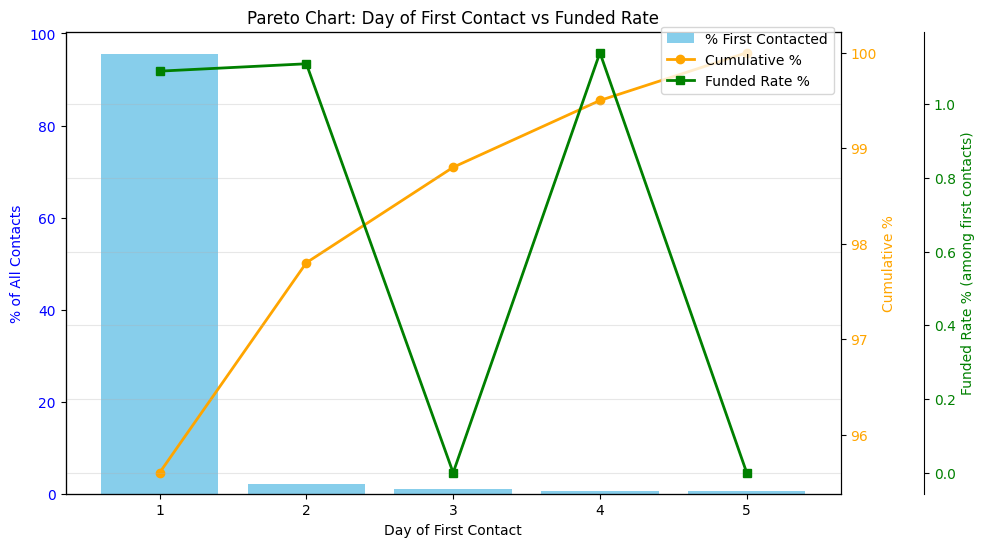

In [54]:
import matplotlib.pyplot as plt

# Data from table
days = daily_first_contact['Day of First Contact']
pct = daily_first_contact['pct_first_contacted']
cum_pct = daily_first_contact['cumulative_pct']
funded_pct = daily_first_contact['funded_rate_pct']

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar: % first contacted per day
ax1.bar(days, pct, color='skyblue', label='% First Contacted')
ax1.set_xlabel('Day of First Contact')
ax1.set_ylabel('% of All Contacts', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis for cumulative (Pareto line)
ax2 = ax1.twinx()
ax2.plot(days, cum_pct, color='orange', marker='o', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative %', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Tertiary line for funded rate
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # offset to avoid overlap
ax3.plot(days, funded_pct, color='green', marker='s', linewidth=2, label='Funded Rate %')
ax3.set_ylabel('Funded Rate % (among first contacts)', color='green')
ax3.tick_params(axis='y', labelcolor='green')

# Titles & legend
plt.title('Pareto Chart: Day of First Contact vs Funded Rate')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Work on leads with known first contact day
df_contacted = df_lead_metrics[df_lead_metrics['first_contact_day'].notna()].copy()

# Limit to days 1–5 (most contacts happen here)
df_contacted = df_contacted[df_contacted['first_contact_day'].between(1, 5)]

# Count first contacts per day per segment
counts = df_contacted.groupby(['first_contact_day', 'Lead Channel Segment'])['Lead ID'].count().unstack(fill_value=0)

# Force days 1–5 as rows (even if zero in some segments)
days_range = pd.Index(range(1, 6), name='Day of First Contact')
counts = counts.reindex(days_range, fill_value=0)

# Total leads per segment (full dataset)
total_per_segment = df_lead_metrics.groupby('Lead Channel Segment')['Lead ID'].count()

# Convert to % of total leads in segment
pivot = counts.copy()
for col in pivot.columns:
    pivot[col] = (pivot[col] / total_per_segment.get(col, 1) * 100).round(1)

# Reorder columns for readability (high-performers first, then partners)
column_order = [
    'Retargeting', 'Direct / Organic', 'Paid Spend', 'Mail',
    'Movoto', 'Digital Buy Partner', 'Other'
]
pivot = pivot[[c for c in column_order if c in pivot.columns]]

print("Percent of Leads Whose First Successful Contact Happened on Each Day — All Segments")
print("(Value = % of all leads in segment with first contact on that day)")
print(pivot.to_string())

# Sum Day 1 only (since Day 0 is missing) and Day 1–2 for comparison
print("\nSum % first contacted on Day 1:")
print(pivot.loc[1])

print("\nSum % first contacted on Day 1–2:")
print(pivot.loc[[1, 2]].sum())

Percent of Leads Whose First Successful Contact Happened on Each Day — All Segments
(Value = % of all leads in segment with first contact on that day)
Lead Channel Segment  Retargeting  Direct / Organic  Paid Spend  Mail  Movoto  Digital Buy Partner  Other
Day of First Contact                                                                                     
1                            83.1              37.1        41.9  11.0    51.8                 24.7   50.0
2                             2.4               0.7         0.7   2.0     1.5                  0.4    0.0
3                             0.4               0.3         0.4   0.0     0.6                  0.2    0.8
4                             0.2               0.2         0.2   0.0     0.4                  0.2    0.0
5                             0.0               0.2         0.2   1.0     0.3                  0.1    0.0

Sum % first contacted on Day 1:
Lead Channel Segment
Retargeting            83.1
Direct / Organic       37

In [68]:
# Filter df_lead_metrics to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function (granular 1-7, then grouped)
def manual_bin(attempts):
    if pd.isna(attempts):
        return 'Missing'
    attempts = int(attempts)
    if attempts == 0:
        return '0'
    elif attempts <= 7:
        return str(attempts)
    elif 8 <= attempts <= 10:
        return '8–10'
    elif 11 <= attempts <= 15:
        return '11–15'
    else:
        return '16+'

df_focus['total_attempts_bin_granular'] = df_focus['total_outbound_attempts'].apply(manual_bin)

# Aggregate by granular bin
granular_funding_focus = df_focus.groupby('total_attempts_bin_granular').agg(
    num_leads=('Lead ID', 'count'),
    funded_count=('ever_funded', 'sum'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format
granular_funding_focus['funded_rate'] = (granular_funding_focus['funded_rate'] * 100).round(2).astype(str) + ' %'
granular_funding_focus['funded_per_1000'] = (granular_funding_focus['funded_count'] / granular_funding_focus['num_leads'] * 1000).round(1)

# Sort bins logically
bin_order = ['0', '1', '2', '3', '4', '5', '6', '7', '8–10', '11–15', '16+', 'Missing']
granular_funding_focus['bin_sort'] = granular_funding_focus['total_attempts_bin_granular'].map({b: i for i, b in enumerate(bin_order)})
granular_funding_focus = granular_funding_focus.sort_values('bin_sort')

print("Granular Funded Rate by Total Outbound Attempts — Movoto + Digital Buy Partner Only")
print(granular_funding_focus[[
    'total_attempts_bin_granular',
    'num_leads',
    'funded_count',
    'funded_rate',
    'funded_per_1000'
]].to_string(index=False))

Granular Funded Rate by Total Outbound Attempts — Movoto + Digital Buy Partner Only
total_attempts_bin_granular  num_leads  funded_count funded_rate  funded_per_1000
                          0       9830             3      0.03 %              0.3
                          1       2472             3      0.12 %              1.2
                          2       1735             2      0.12 %              1.2
                          3       1292             1      0.08 %              0.8
                          4       1084             3      0.28 %              2.8
                          5        773             2      0.26 %              2.6
                          6        520             2      0.38 %              3.8
                          7        385             2      0.52 %              5.2
                       8–10        650             1      0.15 %              1.5
                      11–15        839             2      0.24 %              2.4
              

In [69]:
# Filter to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function for max_attempts_same_day (granular 1-5, then 6+)
def max_day_bin(max_attempts):
    if pd.isna(max_attempts):
        return 'Missing'
    max_attempts = int(max_attempts)
    if max_attempts == 0:
        return '0'
    elif max_attempts <= 5:
        return str(max_attempts)
    else:
        return '6+'

df_focus['max_same_day_bin'] = df_focus['max_attempts_same_day'].apply(max_day_bin)

# Aggregate by granular max same-day bin
granular_max_day = df_focus.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    funded_count=('ever_funded', 'sum'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format
granular_max_day['funded_rate'] = (granular_max_day['funded_rate'] * 100).round(2).astype(str) + ' %'
granular_max_day['funded_per_1000'] = (granular_max_day['funded_count'] / granular_max_day['num_leads'] * 1000).round(1)

# Sort bins logically
bin_order = ['0', '1', '2', '3', '4', '5', '6+', 'Missing']
granular_max_day['bin_sort'] = granular_max_day['max_same_day_bin'].map({b: i for i, b in enumerate(bin_order)})
granular_max_day = granular_max_day.sort_values('bin_sort')

print("Granular Funded Rate by Max Attempts Same-Day — Movoto + Digital Buy Partner Only")
print(granular_max_day[[
    'max_same_day_bin',
    'num_leads',
    'funded_count',
    'funded_rate',
    'funded_per_1000'
]].to_string(index=False))

Granular Funded Rate by Max Attempts Same-Day — Movoto + Digital Buy Partner Only
max_same_day_bin  num_leads  funded_count funded_rate  funded_per_1000
               0       9830             3      0.03 %              0.3
               1       3663             3      0.08 %              0.8
               2       2920             7      0.24 %              2.4
               3       4028             5      0.12 %              1.2
               4       1096             3      0.27 %              2.7
               5        161             1      0.62 %              6.2
              6+         47             0       0.0 %              0.0


In [71]:
# Filter to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function for max_attempts_same_day (granular 1-5, then 6+)
def max_day_bin(max_attempts):
    if pd.isna(max_attempts):
        return 'Missing'
    max_attempts = int(max_attempts)
    if max_attempts == 0:
        return '0'
    elif max_attempts <= 5:
        return str(max_attempts)
    else:
        return '6+'

df_focus['max_same_day_bin'] = df_focus['max_attempts_same_day'].apply(max_day_bin)

# Aggregate: spam rate by max same-day bin
spam_by_max_day = df_focus.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    spam_count=('ever_spam_flagged', 'sum'),
    spam_rate=('ever_spam_flagged', 'mean'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format percentages
spam_by_max_day['spam_rate'] = (spam_by_max_day['spam_rate'] * 100).round(1).astype(str) + ' %'
spam_by_max_day['funded_rate'] = (spam_by_max_day['funded_rate'] * 100).round(2).astype(str) + ' %'
spam_by_max_day['spam_per_1000'] = (spam_by_max_day['spam_count'] / spam_by_max_day['num_leads'] * 1000).round(1)

# Sort bins logically
bin_order = ['0', '1', '2', '3', '4', '5', '6+', 'Missing']
spam_by_max_day['bin_sort'] = spam_by_max_day['max_same_day_bin'].map({b: i for i, b in enumerate(bin_order)})
spam_by_max_day = spam_by_max_day.sort_values('bin_sort')

print("Spam Rate by Max Attempts Same-Day — Movoto + Digital Buy Partner Only")
print(spam_by_max_day[[
    'max_same_day_bin',
    'num_leads',
    'spam_count',
    'spam_rate',
    'spam_per_1000',
    'funded_rate'
]].to_string(index=False))

Spam Rate by Max Attempts Same-Day — Movoto + Digital Buy Partner Only
max_same_day_bin  num_leads  spam_count spam_rate  spam_per_1000 funded_rate
               0       9830         0.0     0.0 %            0.0      0.03 %
               1       3663       226.0     6.2 %           61.7      0.08 %
               2       2920       236.0     8.1 %           80.8      0.24 %
               3       4028       332.0     8.2 %           82.4      0.12 %
               4       1096        88.0     8.0 %           80.3      0.27 %
               5        161         4.0     2.5 %           24.8      0.62 %
              6+         47         2.0     4.3 %           42.6       0.0 %


In [73]:
# Filter to the two segments
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Flag early contact (Day 0 or 1)
df_focus['early_contact'] = df_focus['first_contact_day'].apply(
    lambda x: 'Early (Day 0-1)' if pd.notna(x) and x <= 1 else 'Late or Never'
)

# Aggregate
early_table = df_focus.groupby(['Lead Channel Segment', 'early_contact']).agg(
    num_leads=('Lead ID', 'count'),
    funded=('ever_funded', 'sum'),
    funded_rate=('ever_funded', 'mean')
).reset_index()

# Format rates
early_table['funded_rate'] = (early_table['funded_rate'] * 100).round(2).astype(str) + ' %'

# Add % of segment total
early_table['pct_of_segment'] = (
    early_table.groupby('Lead Channel Segment')['num_leads']
    .transform(lambda x: (x / x.sum() * 100).round(1))
).astype(str) + ' %'

# Pivot for cleaner view (optional — comment out if you prefer long format)
pivot_table = early_table.pivot(
    index='Lead Channel Segment',
    columns='early_contact',
    values=['num_leads', 'funded', 'funded_rate', 'pct_of_segment']
)

print("Early Contact vs Funded Outcome — Movoto & Digital Buy Partner")
print(early_table.to_string(index=False))

# Optional pivot view (easier to read in deck)
print("\nPivoted View (for deck):")
print(pivot_table.to_string())

Early Contact vs Funded Outcome — Movoto & Digital Buy Partner
Lead Channel Segment   early_contact  num_leads  funded funded_rate pct_of_segment
 Digital Buy Partner Early (Day 0-1)       3086       9      0.29 %         24.7 %
 Digital Buy Partner   Late or Never       9423       6      0.06 %         75.3 %
              Movoto Early (Day 0-1)       4787       7      0.15 %         51.8 %
              Movoto   Late or Never       4449       0       0.0 %         48.2 %

Pivoted View (for deck):
                           num_leads                        funded                   funded_rate                pct_of_segment              
early_contact        Early (Day 0-1) Late or Never Early (Day 0-1) Late or Never Early (Day 0-1) Late or Never Early (Day 0-1) Late or Never
Lead Channel Segment                                                                                                                        
Digital Buy Partner             3086          9423               9       

In [75]:
# Work on leads with known first contact day
df_contacted = df_lead_metrics[df_lead_metrics['first_contact_day'].notna()].copy()

# Force days 0–5 as rows (even if zero contacts on some days)
days_range = pd.Index(range(0, 6), name='Day of First Contact (0 = same day)')

# Count first contacts per day per segment
counts = df_contacted.groupby(['first_contact_day', 'Lead Channel Segment'])['Lead ID'].count().unstack(fill_value=0)

# Reindex to include all days 0–5
counts = counts.reindex(days_range, fill_value=0)

# Total leads per segment (full dataset)
total_per_segment = df_lead_metrics.groupby('Lead Channel Segment')['Lead ID'].count()

# Convert counts to % of total leads in segment
pivot = counts.copy()
for col in pivot.columns:
    pivot[col] = (pivot[col] / total_per_segment.get(col, 1) * 100).round(1)

# Reorder columns for focus (high-performers first, then partners)
column_order = [
    'Retargeting', 'Direct / Organic', 'Paid Spend', 'Mail',
    'Movoto', 'Digital Buy Partner', 'Other'
]
pivot = pivot[[c for c in column_order if c in pivot.columns]]

print("Percent of Leads Whose First Successful Contact Happened on Each Day — All Segments")
print("(Value = % of all leads in segment with first contact on that day)")
print(pivot.to_string())

# Sum Day 0–1 for quick check
days_0_1 = pivot.loc[[0, 1]].sum()
print("\nSum % first contacted on Day 0 or 1:")
print(days_0_1)

Percent of Leads Whose First Successful Contact Happened on Each Day — All Segments
(Value = % of all leads in segment with first contact on that day)
Lead Channel Segment                 Retargeting  Direct / Organic  Paid Spend  Mail  Movoto  Digital Buy Partner  Other
Day of First Contact (0 = same day)                                                                                     
0                                            0.0               0.0         0.0   0.0     0.0                  0.0    0.0
1                                           83.1              37.1        41.9  11.0    51.8                 24.7   50.0
2                                            2.4               0.7         0.7   2.0     1.5                  0.4    0.0
3                                            0.4               0.3         0.4   0.0     0.6                  0.2    0.8
4                                            0.2               0.2         0.2   0.0     0.4                  0.2    0.0
5 

In [76]:
# Filter to Day 1 calls only
df_day1 = df_attempts[df_attempts['days_since_creation'] == 1].copy()

# Count attempts per lead on Day 1
day1_attempts = df_day1.groupby('Lead ID').size().reset_index(name='attempts_day1')

# Merge segment info
day1_attempts = day1_attempts.merge(
    df_lead_metrics[['Lead ID', 'Lead Channel Segment']],
    on='Lead ID',
    how='left'
)

# Focus on key segments
focus_segments = ['Movoto', 'Digital Buy Partner', 'Direct / Organic', 'Paid Spend', 'Retargeting']
day1_focus = day1_attempts[day1_attempts['Lead Channel Segment'].isin(focus_segments)]

# % of Day 1 lead-days with exactly 3 attempts per segment
day1_summary = day1_focus.groupby('Lead Channel Segment').agg(
    lead_days_day1=('Lead ID', 'count'),               # total Day 1 lead-days with any attempt
    days_with_3_attempts=('attempts_day1', lambda x: (x == 3).sum())
).reset_index()

day1_summary['pct_day1_3_attempts'] = (
    day1_summary['days_with_3_attempts'] / day1_summary['lead_days_day1'] * 100
).round(1).astype(str) + ' %'

print("Current % of Day 1 Lead-Days Reaching Exactly 3 Attempts — by Segment")
print(day1_summary.to_string(index=False))

Current % of Day 1 Lead-Days Reaching Exactly 3 Attempts — by Segment
Lead Channel Segment  lead_days_day1  days_with_3_attempts pct_day1_3_attempts
 Digital Buy Partner            5242                  1155              22.0 %
    Direct / Organic            1628                   296              18.2 %
              Movoto            6618                  1162              17.6 %
          Paid Spend            2897                   539              18.6 %
         Retargeting             478                    22               4.6 %


In [79]:
# Filter to Day 1 calls only
df_day1 = df_attempts[df_attempts['days_since_creation']  <=1].copy()

# Count attempts per lead on Day 1
day1_attempts = df_day1.groupby('Lead ID').size().reset_index(name='attempts_day1')

# Merge segment info
day1_attempts = day1_attempts.merge(
    df_lead_metrics[['Lead ID', 'Lead Channel Segment']],
    on='Lead ID',
    how='left'
)

# Focus on key segments
focus_segments = ['Movoto', 'Digital Buy Partner', 'Direct / Organic', 'Paid Spend', 'Retargeting']
day1_focus = day1_attempts[day1_attempts['Lead Channel Segment'].isin(focus_segments)]

# Calculate % of Day 1 attempted leads that hit 1, 2, or 3 attempts per segment
day1_summary = day1_focus.groupby('Lead Channel Segment').agg(
    lead_days_day1=('Lead ID', 'count'),  # total Day 1 attempted leads
    days_with_1_attempt=('attempts_day1', lambda x: (x == 1).sum()),
    days_with_2_attempts=('attempts_day1', lambda x: (x == 2).sum()),
    days_with_3_attempts=('attempts_day1', lambda x: (x == 3).sum())
).reset_index()

# Calculate percentages
day1_summary['pct_1_attempt'] = (day1_summary['days_with_1_attempt'] / day1_summary['lead_days_day1'] * 100).round(1).astype(str) + ' %'
day1_summary['pct_2_attempts'] = (day1_summary['days_with_2_attempts'] / day1_summary['lead_days_day1'] * 100).round(1).astype(str) + ' %'
day1_summary['pct_3_attempts'] = (day1_summary['days_with_3_attempts'] / day1_summary['lead_days_day1'] * 100).round(1).astype(str) + ' %'

print("Day 1 Attempt Distribution — % of Day 1 Attempted Leads Reaching 1, 2, or 3 Attempts")
print(day1_summary[[
    'Lead Channel Segment',
    'lead_days_day1',
    'pct_1_attempt',
    'pct_2_attempts',
    'pct_3_attempts'
]].to_string(index=False))

Day 1 Attempt Distribution — % of Day 1 Attempted Leads Reaching 1, 2, or 3 Attempts
Lead Channel Segment  lead_days_day1 pct_1_attempt pct_2_attempts pct_3_attempts
 Digital Buy Partner            5254        28.5 %         24.1 %         20.2 %
    Direct / Organic            1633        38.5 %         25.7 %         17.6 %
              Movoto            6629        36.6 %         24.7 %         17.9 %
          Paid Spend            2901        35.3 %         26.2 %         16.9 %
         Retargeting             482        64.9 %         24.7 %          7.1 %


In [80]:
# --- Force re-parse (paranoia mode) ---
df_leads['Lead Created (ET) Time'] = pd.to_datetime(
    df_leads['Lead Created (ET) Time'], 
    errors='coerce'
)

# --- Extract hour and day of week ---
df_leads['creation_hour'] = df_leads['Lead Created (ET) Time'].dt.hour
df_leads['creation_dow'] = df_leads['Lead Created (ET) Time'].dt.day_name()

# --- Distribution by hour of day ---
hour_dist = df_leads['creation_hour'].value_counts().sort_index()

print("Lead Creation by Hour of Day (0–23):")
print(hour_dist.to_string())

print("\n% created outside 9am–5pm (typical business hours):")
outside_business = df_leads[
    ~df_leads['creation_hour'].between(9, 17)
].shape[0] / df_leads.shape[0] * 100
print(f"{outside_business:.1f}%")

# --- Distribution by day of week ---
dow_dist = df_leads['creation_dow'].value_counts()

print("\nLead Creation by Day of Week:")
print(dow_dist.to_string())

print("\n% created on weekends (Sat/Sun):")
weekend_pct = df_leads[
    df_leads['creation_dow'].isin(['Saturday', 'Sunday'])
].shape[0] / df_leads.shape[0] * 100
print(f"{weekend_pct:.1f}%")

Lead Creation by Hour of Day (0–23):
creation_hour
0.0      776
1.0      586
2.0      357
3.0      296
4.0      277
5.0      306
6.0      379
7.0      552
8.0     1094
9.0     1962
10.0    2291
11.0    2445
12.0    2584
13.0    2763
14.0    2724
15.0    2525
16.0    2596
17.0    2090
18.0    1869
19.0    1713
20.0    1549
21.0    1402
22.0    1214
23.0     819

% created outside 9am–5pm (typical business hours):
37.5%

Lead Creation by Day of Week:
creation_dow
Wednesday    6271
Tuesday      5967
Thursday     5886
Monday       5382
Friday       5332
Sunday       3223
Saturday     3108

% created on weekends (Sat/Sun):
18.0%


In [82]:
# Top 10 reps (from your earlier output)
top_reps = [
    'Quetanah Modeste', 'Brae Humbert', 'Emmanuel Gonzalez', 'Merleana Burke',
    'Kelda McDonald', 'Frani Henry', 'Bernetta Felix', 'Connor Bourn',
    'Nikita Lartchenko', 'Shannon Marshall'
]

# Filter to Movoto/DBP calls that were Transfer Sent
transfer_calls = df_attempts[
    (df_attempts['Outcome'] == 'Transfer Sent') &
    (df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner']))
].copy()

# Flag top reps
transfer_calls['is_top_rep'] = transfer_calls['Team Member Name'].isin(top_reps)

# Extract hour and day of week for Transfer Sent calls
transfer_calls['call_hour'] = transfer_calls['Activity (ET) Time'].dt.hour
transfer_calls['call_dow'] = transfer_calls['Activity (ET) Time'].dt.day_name()

# Aggregate by top/other
timing_comparison = transfer_calls.groupby('is_top_rep').agg(
    num_transfer_calls=('Activity ID (Surrogate)', 'count'),
    avg_hour=('call_hour', 'mean'),
    most_common_dow=('call_dow', lambda x: x.mode()[0] if not x.empty else 'N/A')
).reset_index()

timing_comparison['is_top_rep'] = timing_comparison['is_top_rep'].map({True: 'Top 10 Reps', False: 'Other Reps'})

print("Timing of Transfer Sent Calls — Top 10 Reps vs Others (Movoto/DBP only)")
print(timing_comparison.to_string(index=False))

# Bonus: Hour distribution for top reps
print("\nHour distribution for Top 10 Reps' Transfer Sent calls:")
print(
    transfer_calls[transfer_calls['is_top_rep'] == True]
    ['call_hour']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
    .astype(str) + ' %'
)

print("\nHour distribution for Other Reps' Transfer Sent calls:")
print(
    transfer_calls[transfer_calls['is_top_rep'] == False]
    ['call_hour']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
    .astype(str) + ' %'
)

Timing of Transfer Sent Calls — Top 10 Reps vs Others (Movoto/DBP only)
 is_top_rep  num_transfer_calls  avg_hour most_common_dow
 Other Reps                1615 12.443963         Tuesday
Top 10 Reps                1246 12.110754         Tuesday

Hour distribution for Top 10 Reps' Transfer Sent calls:
call_hour
8      6.7 %
9     17.4 %
10    12.8 %
11     9.7 %
12     8.1 %
13    10.4 %
14    10.2 %
15    11.4 %
16     7.9 %
17     4.4 %
18     0.9 %
19     0.2 %
Name: proportion, dtype: str

Hour distribution for Other Reps' Transfer Sent calls:
call_hour
8      4.1 %
9     14.5 %
10    12.6 %
11     9.7 %
12    10.1 %
13    11.8 %
14     9.7 %
15    10.5 %
16     9.8 %
17     5.2 %
18     1.9 %
Name: proportion, dtype: str


In [84]:
# Extract activity date
df_attempts['activity_date'] = df_attempts['Activity (ET) Time'].dt.date

# Total outbound calls per day
daily_capacity = df_attempts[df_attempts['Direction'] == 'Outbound'].groupby('activity_date').size().reset_index(name='total_outbound_calls')

# Sort by date
daily_capacity = daily_capacity.sort_values('activity_date')

# Print the full table
print("Full Daily Outbound Call Volume (all days):")
print(daily_capacity.to_string(index=False))

# Summary stats for quick view
print("\nSummary Statistics:")
print(f"Number of days with data: {len(daily_capacity)}")
print(f"Average daily outbound calls: {daily_capacity['total_outbound_calls'].mean():.0f}")
print(f"Median daily outbound calls: {daily_capacity['total_outbound_calls'].median():.0f}")
print(f"Max daily outbound calls: {daily_capacity['total_outbound_calls'].max()}")
print(f"Min daily outbound calls: {daily_capacity['total_outbound_calls'].min()}")
print(f"Standard deviation: {daily_capacity['total_outbound_calls'].std():.0f}")

Full Daily Outbound Call Volume (all days):
activity_date  total_outbound_calls
   2025-08-19                     1
   2025-11-01                    44
   2025-11-02                   120
   2025-11-03                   600
   2025-11-04                   695
   2025-11-05                  1032
   2025-11-06                  1056
   2025-11-07                   856
   2025-11-08                    86
   2025-11-09                    93
   2025-11-10                  1426
   2025-11-11                  1613
   2025-11-12                  1511
   2025-11-13                  1527
   2025-11-14                  1305
   2025-11-15                    76
   2025-11-16                    96
   2025-11-17                  2494
   2025-11-18                  2142
   2025-11-19                  2182
   2025-11-20                  1833
   2025-11-21                  1292
   2025-11-22                   425
   2025-11-23                   404
   2025-11-24                  1999
   2025-11-25       

In [85]:
# Manual bin function for max_attempts_same_day (granular 1-5, then 6+)
def max_day_bin(max_attempts):
    if pd.isna(max_attempts):
        return 'Missing'
    max_attempts = int(max_attempts)
    if max_attempts == 0:
        return '0'
    elif max_attempts <= 5:
        return str(max_attempts)
    else:
        return '6+'

df_lead_metrics['max_same_day_bin'] = df_lead_metrics['max_attempts_same_day'].apply(max_day_bin)

# Aggregate by bin
granular_opp = df_lead_metrics.groupby('max_same_day_bin', observed=True).agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean')
).reset_index()

# Format
granular_opp['opp_rate'] = (granular_opp['opp_rate'] * 100).round(2).astype(str) + ' %'
granular_opp['opp_per_1000'] = (granular_opp['opp_count'] / granular_opp['num_leads'] * 1000).round(1)

# Sort bins logically
bin_order = ['0', '1', '2', '3', '4', '5', '6+', 'Missing']
granular_opp['bin_sort'] = granular_opp['max_same_day_bin'].map({b: i for i, b in enumerate(bin_order)})
granular_opp = granular_opp.sort_values('bin_sort')

print("Granular Opportunity Rate by Max Attempts Same-Day — All Segments")
print(granular_opp[[
    'max_same_day_bin',
    'num_leads',
    'opp_count',
    'opp_rate',
    'opp_per_1000'
]].to_string(index=False))

Granular Opportunity Rate by Max Attempts Same-Day — All Segments
max_same_day_bin  num_leads  opp_count opp_rate  opp_per_1000
               0      13912       1359   9.77 %          97.7
               1       5580       2456  44.01 %         440.1
               2       4300       2246  52.23 %         522.3
               3       5319       1855  34.87 %         348.7
               4       1531        617   40.3 %         403.0
               5        276        152  55.07 %         550.7
              6+         98         71  72.45 %         724.5


In [87]:
# Filter df_lead_metrics to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function for max_attempts_same_day (granular 1-5, then 6+)
def max_day_bin(max_attempts):
    if pd.isna(max_attempts):
        return 'Missing'
    max_attempts = int(max_attempts)
    if max_attempts == 0:
        return '0'
    elif max_attempts <= 5:
        return str(max_attempts)
    else:
        return '6+'

df_focus['max_same_day_bin'] = df_focus['max_attempts_same_day'].apply(max_day_bin)

# Aggregate by granular bin
granular_opp_focus = df_focus.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean')
).reset_index()

# Format
granular_opp_focus['opp_rate'] = (granular_opp_focus['opp_rate'] * 100).round(2).astype(str) + ' %'
granular_opp_focus['opp_per_1000'] = (granular_opp_focus['opp_count'] / granular_opp_focus['num_leads'] * 1000).round(1)

# Sort bins logically
bin_order = ['0', '1', '2', '3', '4', '5', '6+', 'Missing']
granular_opp_focus['bin_sort'] = granular_opp_focus['max_same_day_bin'].map({b: i for i, b in enumerate(bin_order)})
granular_opp_focus = granular_opp_focus.sort_values('bin_sort')

print("Granular Opportunity Rate by Max Attempts Same-Day — Movoto + Digital Buy Partner Only")
print(granular_opp_focus[[
    'max_same_day_bin',
    'num_leads',
    'opp_count',
    'opp_rate',
    'opp_per_1000'
]].to_string(index=False))

Granular Opportunity Rate by Max Attempts Same-Day — Movoto + Digital Buy Partner Only
max_same_day_bin  num_leads  opp_count opp_rate  opp_per_1000
               0       9830        686   6.98 %          69.8
               1       3663       1391  37.97 %         379.7
               2       2920       1275  43.66 %         436.6
               3       4028       1099  27.28 %         272.8
               4       1096        372  33.94 %         339.4
               5        161         74  45.96 %         459.6
              6+         47         31  65.96 %         659.6


In [88]:
# Filter to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function for max_attempts_same_day (granular 1-5, then 6+)
def max_day_bin(max_attempts):
    if pd.isna(max_attempts):
        return 'Missing'
    max_attempts = int(max_attempts)
    if max_attempts == 0:
        return '0'
    elif max_attempts <= 5:
        return str(max_attempts)
    else:
        return '6+'

df_focus['max_same_day_bin'] = df_focus['max_attempts_same_day'].apply(max_day_bin)

# Aggregate: both opp and spam metrics
granular_table = df_focus.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean'),
    spam_count=('ever_spam_flagged', 'sum'),
    spam_rate=('ever_spam_flagged', 'mean')
).reset_index()

# Format rates
granular_table['opp_rate'] = (granular_table['opp_rate'] * 100).round(2).astype(str) + ' %'
granular_table['opp_per_1000'] = (granular_table['opp_count'] / granular_table['num_leads'] * 1000).round(1)
granular_table['spam_rate'] = (granular_table['spam_rate'] * 100).round(1).astype(str) + ' %'
granular_table['spam_per_1000'] = (granular_table['spam_count'] / granular_table['num_leads'] * 1000).round(1)

# Sort bins logically
bin_order = ['0', '1', '2', '3', '4', '5', '6+', 'Missing']
granular_table['bin_sort'] = granular_table['max_same_day_bin'].map({b: i for i, b in enumerate(bin_order)})
granular_table = granular_table.sort_values('bin_sort')

print("Opp Gain vs Spam Risk by Max Attempts Same-Day — Movoto + Digital Buy Partner Only")
print(granular_table[[
    'max_same_day_bin',
    'num_leads',
    'opp_count', 'opp_rate', 'opp_per_1000',
    'spam_count', 'spam_rate', 'spam_per_1000'
]].to_string(index=False))

Opp Gain vs Spam Risk by Max Attempts Same-Day — Movoto + Digital Buy Partner Only
max_same_day_bin  num_leads  opp_count opp_rate  opp_per_1000  spam_count spam_rate  spam_per_1000
               0       9830        686   6.98 %          69.8         0.0     0.0 %            0.0
               1       3663       1391  37.97 %         379.7       226.0     6.2 %           61.7
               2       2920       1275  43.66 %         436.6       236.0     8.1 %           80.8
               3       4028       1099  27.28 %         272.8       332.0     8.2 %           82.4
               4       1096        372  33.94 %         339.4        88.0     8.0 %           80.3
               5        161         74  45.96 %         459.6         4.0     2.5 %           24.8
              6+         47         31  65.96 %         659.6         2.0     4.3 %           42.6


In [89]:
# Manual bin function for total_outbound_attempts (granular 1-7, then grouped)
def total_attempts_bin(attempts):
    if pd.isna(attempts):
        return 'Missing'
    attempts = int(attempts)
    if attempts == 0:
        return '0'
    elif attempts <= 7:
        return str(attempts)
    elif 8 <= attempts <= 10:
        return '8–10'
    elif 11 <= attempts <= 15:
        return '11–15'
    else:
        return '16+'

df_lead_metrics['total_attempts_bin_granular'] = df_lead_metrics['total_outbound_attempts'].apply(total_attempts_bin)

# Aggregate by bin
granular_opp = df_lead_metrics.groupby('total_attempts_bin_granular', observed=True).agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean')
).reset_index()

# Format
granular_opp['opp_rate'] = (granular_opp['opp_rate'] * 100).round(2).astype(str) + ' %'
granular_opp['opp_per_1000'] = (granular_opp['opp_count'] / granular_opp['num_leads'] * 1000).round(1)

# Logical sort
bin_order = ['0', '1', '2', '3', '4', '5', '6', '7', '8–10', '11–15', '16+', 'Missing']
granular_opp['bin_sort'] = granular_opp['total_attempts_bin_granular'].map({b: i for i, b in enumerate(bin_order)})
granular_opp = granular_opp.sort_values('bin_sort')

print("Opportunity Rate by Total Outbound Attempts — All Segments (Granular)")
print(granular_opp[[
    'total_attempts_bin_granular',
    'num_leads',
    'opp_count',
    'opp_rate',
    'opp_per_1000'
]].to_string(index=False))

Opportunity Rate by Total Outbound Attempts — All Segments (Granular)
total_attempts_bin_granular  num_leads  opp_count opp_rate  opp_per_1000
                          0      13912       1359   9.77 %          97.7
                          1       3672       1614  43.95 %         439.5
                          2       2665       1363  51.14 %         511.4
                          3       1977       1069  54.07 %         540.7
                          4       1587        818  51.54 %         515.4
                          5       1130        596  52.74 %         527.4
                          6        812        434  53.45 %         534.5
                          7        585        326  55.73 %         557.3
                       8–10        947        487  51.43 %         514.3
                      11–15       1043        305  29.24 %         292.4
                        16+       2686        385  14.33 %         143.3


In [90]:
# Filter df_lead_metrics to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function (granular 1-7, then grouped 8+)
def total_attempts_bin(attempts):
    if pd.isna(attempts):
        return 'Missing'
    attempts = int(attempts)
    if attempts == 0:
        return '0'
    elif attempts <= 7:
        return str(attempts)
    elif 8 <= attempts <= 10:
        return '8–10'
    elif 11 <= attempts <= 15:
        return '11–15'
    else:
        return '16+'

df_focus['total_attempts_bin_granular'] = df_focus['total_outbound_attempts'].apply(total_attempts_bin)

# Aggregate by granular bin
granular_opp_focus = df_focus.groupby('total_attempts_bin_granular', observed=True).agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean')
).reset_index()

# Format
granular_opp_focus['opp_rate'] = (granular_opp_focus['opp_rate'] * 100).round(2).astype(str) + ' %'
granular_opp_focus['opp_per_1000'] = (granular_opp_focus['opp_count'] / granular_opp_focus['num_leads'] * 1000).round(1)

# Logical sort
bin_order = ['0', '1', '2', '3', '4', '5', '6', '7', '8–10', '11–15', '16+', 'Missing']
granular_opp_focus['bin_sort'] = granular_opp_focus['total_attempts_bin_granular'].map({b: i for i, b in enumerate(bin_order)})
granular_opp_focus = granular_opp_focus.sort_values('bin_sort')

print("Opportunity Rate by Total Outbound Attempts — Movoto + Digital Buy Partner Only (Granular)")
print(granular_opp_focus[[
    'total_attempts_bin_granular',
    'num_leads',
    'opp_count',
    'opp_rate',
    'opp_per_1000'
]].to_string(index=False))

Opportunity Rate by Total Outbound Attempts — Movoto + Digital Buy Partner Only (Granular)
total_attempts_bin_granular  num_leads  opp_count opp_rate  opp_per_1000
                          0       9830        686   6.98 %          69.8
                          1       2472        925  37.42 %         374.2
                          2       1735        766  44.15 %         441.5
                          3       1292        575   44.5 %         445.0
                          4       1084        473  43.63 %         436.3
                          5        773        345  44.63 %         446.3
                          6        520        225  43.27 %         432.7
                          7        385        179  46.49 %         464.9
                       8–10        650        273   42.0 %         420.0
                      11–15        839        216  25.74 %         257.4
                        16+       2165        265  12.24 %         122.4


In [91]:
# Filter to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Manual bin function for max_attempts_same_day (granular 1-5, then 6+)
def max_day_bin(max_attempts):
    if pd.isna(max_attempts):
        return 'Missing'
    max_attempts = int(max_attempts)
    if max_attempts == 0:
        return '0'
    elif max_attempts <= 5:
        return str(max_attempts)
    else:
        return '6+'

df_focus['max_same_day_bin'] = df_focus['max_attempts_same_day'].apply(max_day_bin)

# Aggregate: opp + spam metrics
granular_table = df_focus.groupby('max_same_day_bin').agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean'),
    spam_count=('ever_spam_flagged', 'sum'),
    spam_rate=('ever_spam_flagged', 'mean')
).reset_index()

# Format
granular_table['opp_rate'] = (granular_table['opp_rate'] * 100).round(2).astype(str) + ' %'
granular_table['opp_per_1000'] = (granular_table['opp_count'] / granular_table['num_leads'] * 1000).round(1)
granular_table['spam_rate'] = (granular_table['spam_rate'] * 100).round(1).astype(str) + ' %'
granular_table['spam_per_1000'] = (granular_table['spam_count'] / granular_table['num_leads'] * 1000).round(1)

# Logical sort
bin_order = ['0', '1', '2', '3', '4', '5', '6+', 'Missing']
granular_table['bin_sort'] = granular_table['max_same_day_bin'].map({b: i for i, b in enumerate(bin_order)})
granular_table = granular_table.sort_values('bin_sort')

print("Opp Gain vs Spam Risk by Max Attempts Same-Day — Movoto + Digital Buy Partner Only")
print(granular_table[[
    'max_same_day_bin',
    'num_leads',
    'opp_count', 'opp_rate', 'opp_per_1000',
    'spam_count', 'spam_rate', 'spam_per_1000'
]].to_string(index=False))

Opp Gain vs Spam Risk by Max Attempts Same-Day — Movoto + Digital Buy Partner Only
max_same_day_bin  num_leads  opp_count opp_rate  opp_per_1000  spam_count spam_rate  spam_per_1000
               0       9830        686   6.98 %          69.8         0.0     0.0 %            0.0
               1       3663       1391  37.97 %         379.7       226.0     6.2 %           61.7
               2       2920       1275  43.66 %         436.6       236.0     8.1 %           80.8
               3       4028       1099  27.28 %         272.8       332.0     8.2 %           82.4
               4       1096        372  33.94 %         339.4        88.0     8.0 %           80.3
               5        161         74  45.96 %         459.6         4.0     2.5 %           24.8
              6+         47         31  65.96 %         659.6         2.0     4.3 %           42.6


In [92]:
# Step 1: Find leads attempted on Day 1
day1_attempted_leads = df_attempts[
    df_attempts['days_since_creation'] == 1
]['Lead ID'].unique()

# Step 2: Flag in df_lead_metrics
df_lead_metrics['attempted_on_day1'] = df_lead_metrics['Lead ID'].isin(day1_attempted_leads).astype(int)

# Step 3: Compare opp rate between groups
opp_by_day1 = df_lead_metrics.groupby('attempted_on_day1').agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean')
).reset_index()

opp_by_day1['attempted_on_day1'] = opp_by_day1['attempted_on_day1'].map({
    1: 'At least 1 attempt on Day 1',
    0: 'No attempts on Day 1'
})

opp_by_day1['opp_rate'] = (opp_by_day1['opp_rate'] * 100).round(1).astype(str) + ' %'
opp_by_day1['opp_per_1000'] = (opp_by_day1['opp_count'] / opp_by_day1['num_leads'] * 1000).round(1)

print("Opportunity Rate: Leads Attempted on Day 1 vs Not Attempted on Day 1")
print(opp_by_day1.to_string(index=False))

Opportunity Rate: Leads Attempted on Day 1 vs Not Attempted on Day 1
          attempted_on_day1  num_leads  opp_count opp_rate  opp_per_1000
       No attempts on Day 1      14036       1431   10.2 %         102.0
At least 1 attempt on Day 1      16980       7325   43.1 %         431.4


In [94]:
# Filter df_lead_metrics to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# Step 1: Find leads attempted on Day 1 (within the filtered set)
day1_attempted_leads = df_attempts[
    (df_attempts['days_since_creation'] == 1) &
    (df_attempts['Lead Channel Segment'].isin(focus_segments))
]['Lead ID'].unique()

# Flag in df_focus
df_focus['attempted_on_day1'] = df_focus['Lead ID'].isin(day1_attempted_leads).astype(int)

# Step 2: Compare opp rate between groups
opp_by_day1_focus = df_focus.groupby('attempted_on_day1').agg(
    num_leads=('Lead ID', 'count'),
    opp_count=('ever_opportunity', 'sum'),
    opp_rate=('ever_opportunity', 'mean')
).reset_index()

opp_by_day1_focus['attempted_on_day1'] = opp_by_day1_focus['attempted_on_day1'].map({
    1: 'At least 1 attempt on Day 1',
    0: 'No attempts on Day 1'
})

opp_by_day1_focus['opp_rate'] = (opp_by_day1_focus['opp_rate'] * 100).round(1).astype(str) + ' %'
opp_by_day1_focus['opp_per_1000'] = (opp_by_day1_focus['opp_count'] / opp_by_day1_focus['num_leads'] * 1000).round(1)

print("Opportunity Rate: Day 1 Attempted vs Not Attempted — Movoto + Digital Buy Partner Only")
print(opp_by_day1_focus.to_string(index=False))

Opportunity Rate: Day 1 Attempted vs Not Attempted — Movoto + Digital Buy Partner Only
          attempted_on_day1  num_leads  opp_count opp_rate  opp_per_1000
       No attempts on Day 1       9885        718    7.3 %          72.6
At least 1 attempt on Day 1      11860       4210   35.5 %         355.0


In [95]:
# Filter to Movoto and Digital Buy Partner only
focus_segments = ['Movoto', 'Digital Buy Partner']
df_focus = df_lead_metrics[df_lead_metrics['Lead Channel Segment'].isin(focus_segments)].copy()

# 1. Leaked opps: opp = 1 but file started = 0
leaked = df_focus[
    (df_focus['ever_opportunity'] == 1) & 
    (df_focus['ever_file_started'] == 0)
].copy()
leaked['group'] = 'Leaked (Opp but no File Started)'

# 2. Successful opps: opp = 1 and file started = 1
successful = df_focus[
    (df_focus['ever_opportunity'] == 1) & 
    (df_focus['ever_file_started'] == 1)
].copy()
successful['group'] = 'Successful (Opp → File Started)'

# Combine
opp_groups = pd.concat([leaked, successful])

# 3. Summarize LO/Qual involvement
comparison = opp_groups.groupby('group').agg(
    num_opps=('Lead ID', 'count'),
    had_qual_lo_call=('had_qual_call', 'sum'),
    pct_had_qual_lo_call=('had_qual_call', 'mean')
).reset_index()

comparison['pct_had_qual_lo_call'] = (comparison['pct_had_qual_lo_call'] * 100).round(1).astype(str) + ' %'

print("Comparison: LO/Qual Involvement in Leaked vs Successful Opps — Movoto + DBP Only")
print(comparison.to_string(index=False))

Comparison: LO/Qual Involvement in Leaked vs Successful Opps — Movoto + DBP Only
                           group  num_opps  had_qual_lo_call pct_had_qual_lo_call
Leaked (Opp but no File Started)      3667            1100.0               30.0 %
 Successful (Opp → File Started)      1261             814.0               64.6 %


In [96]:
# Define LO/Qual roles (from earlier output)
lo_roles = [
    'Loan Prospector',
    'Loan Officer Assistant',
    'Loan Advisor',
    'Sr Loan Advisor'
]

# Filter to calls by these roles
lo_calls = df_attempts[df_attempts['Team Member Role'].isin(lo_roles)].copy()

# Extract date
lo_calls['activity_date'] = lo_calls['Activity (ET) Time'].dt.date

# Aggregate daily calls by LO/Qual roles
daily_lo_capacity = lo_calls.groupby('activity_date').size().reset_index(name='lo_calls_per_day')

# Sort by date
daily_lo_capacity = daily_lo_capacity.sort_values('activity_date')

# Print full table (or head/tail if too long)
print("Daily LO/Qual Role Call Volume (all days):")
print(daily_lo_capacity.to_string(index=False))

# Summary stats
print("\nLO/Qual Role Capacity Summary:")
print(f"Number of days with LO/Qual calls: {len(daily_lo_capacity)}")
print(f"Average daily LO/Qual calls: {daily_lo_capacity['lo_calls_per_day'].mean():.0f}")
print(f"Median daily LO/Qual calls: {daily_lo_capacity['lo_calls_per_day'].median():.0f}")
print(f"Max daily LO/Qual calls: {daily_lo_capacity['lo_calls_per_day'].max()}")
print(f"Min daily LO/Qual calls: {daily_lo_capacity['lo_calls_per_day'].min()}")
print(f"Standard deviation: {daily_lo_capacity['lo_calls_per_day'].std():.0f}")

Daily LO/Qual Role Call Volume (all days):
activity_date  lo_calls_per_day
   2025-11-01                44
   2025-11-02               120
   2025-11-03               414
   2025-11-04               464
   2025-11-05               717
   2025-11-06               670
   2025-11-07               497
   2025-11-08                51
   2025-11-09                93
   2025-11-10              1004
   2025-11-11               760
   2025-11-12               544
   2025-11-13               516
   2025-11-14               353
   2025-11-15                76
   2025-11-16                96
   2025-11-17               288
   2025-11-18               224
   2025-11-19               216
   2025-11-20               207
   2025-11-21               147
   2025-11-22                68
   2025-11-23                35
   2025-11-24               224
   2025-11-25               212
   2025-11-26               121
   2025-11-28               122
   2025-11-29                30
   2025-11-30                

In [99]:
# ────────────────────────────────────────────────
# 1. Define the two groups of outcomes
# ────────────────────────────────────────────────

disqual_outcomes = [
    'Add to DNC',
    'Bad/Disconnected Phone',
    'Fake Lead/Fake Data',
    'Hung Up',
    'Nurture - No Benefit',
    'Nurture - Went With Another Lender',
    'Nurture - Communication Issues',
    'Nurture - Unsupported Loan Type',
    'Nurture - Cash Buyer',
    'Nurture - No Down Payment / Assets - DPA Needed - Unqualified',
    'Nurture - Bankruptcy',
    'Nurture - Foreclosure',
    "Nurture - Can't Pass AUS",
    'Nurture - Unfit for Appraisal',
    'Nurture - Title Seasoning',
    "Nurture - Pricing: Can't Pass Points & Fees",
    'Nurture - Personal Loan',
    'Nurture - Buyer Not Moving Forward',
    'Pitch Turned Down'
]

qual_outcomes = [
    'Transfer Sent',
    'Appointment Set',
    'Nurture - Credit Score',
    'Nurture - Income',
    'Nurture - Loan Amount Under 100k',
    'Nurture - No Down Payment / Assets - Plan to Save Up',
    'Nurture - Property Type',
    'Application Started',
    'Application Completed',
    'Forward to Servicing/Care',
    'Calendly Appointment Confirmed',
    'Pitch Completed',
    'Pitch Attempt',
    'Agent - Called Follow Up',
    'Agent - Pitch Completed',
    'Called - Follow Up',
    'Nurture - Missed/Late Payments',
    'Nurture - Land',
    'Nurture - Capped on Equity: Based on Credit Score',
    'Nurture - Self Employed',
    'Send to QC'
]

all_relevant_outcomes = set(disqual_outcomes + qual_outcomes)

# ────────────────────────────────────────────────
# 2. Filter df_attempts to Movoto + DBP only
# ────────────────────────────────────────────────

df_focus = df_attempts[
    df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])
].copy()

# ────────────────────────────────────────────────
# 3. Identify leaked vs successful opps (using df_lead_metrics)
# ────────────────────────────────────────────────

leaked_ids = df_lead_metrics[
    (df_lead_metrics['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])) &
    (df_lead_metrics['ever_opportunity'] == 1) &
    (df_lead_metrics['ever_file_started'] == 0)
]['Lead ID'].tolist()

successful_ids = df_lead_metrics[
    (df_lead_metrics['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])) &
    (df_lead_metrics['ever_opportunity'] == 1) &
    (df_lead_metrics['ever_file_started'] == 1)
]['Lead ID'].tolist()

# ────────────────────────────────────────────────
# 4. Get calls for these leads only
# ────────────────────────────────────────────────

leaked_calls = df_focus[df_focus['Lead ID'].isin(leaked_ids)].copy()
successful_calls = df_focus[df_focus['Lead ID'].isin(successful_ids)].copy()

leaked_calls['group'] = 'Leaked Opps'
successful_calls['group'] = 'Successful Opps'

# Combine
calls_both = pd.concat([leaked_calls, successful_calls])

# ────────────────────────────────────────────────
# 5. Group outcomes into Disqual / Qual / Other
# ────────────────────────────────────────────────

def group_outcome(outcome):
    if outcome in disqual_outcomes:
        return 'Disqualification'
    elif outcome in qual_outcomes:
        return 'Qualification'
    else:
        return 'Other'

calls_both['outcome_group'] = calls_both['Outcome'].apply(group_outcome)

# ────────────────────────────────────────────────
# 6. Aggregate counts and percentages
# ────────────────────────────────────────────────

outcome_summary = calls_both.groupby(['group', 'outcome_group']).size().reset_index(name='call_count')

# Pivot to wide format
pivot_summary = outcome_summary.pivot(
    index='outcome_group',
    columns='group',
    values='call_count'
).fillna(0)

# Calculate percentages
pivot_summary['Leaked %'] = (pivot_summary['Leaked Opps'] / pivot_summary['Leaked Opps'].sum() * 100).round(1)
pivot_summary['Successful %'] = (pivot_summary['Successful Opps'] / pivot_summary['Successful Opps'].sum() * 100).round(1)

# Sort by Leaked % descending
pivot_summary = pivot_summary.sort_values('Leaked %', ascending=False)

print("Outcome Mix (Disqual vs Qual vs Other) — Leaked vs Successful Opps in Movoto + DBP")
print(pivot_summary[['Leaked Opps', 'Leaked %', 'Successful Opps', 'Successful %']].to_string())

Outcome Mix (Disqual vs Qual vs Other) — Leaked vs Successful Opps in Movoto + DBP
group             Leaked Opps  Leaked %  Successful Opps  Successful %
outcome_group                                                         
Other                   11078      72.9             3240          57.6
Qualification            2984      19.6             2044          36.4
Disqualification         1143       7.5              339           6.0


In [100]:
# ────────────────────────────────────────────────
# 1. Define the "Other" outcomes (from your full list, excluding Disqual and Qual)
# ────────────────────────────────────────────────

other_outcomes = [
    'No Answer', 'Left Voicemail', 'Redial', 'Hold Time Exceeded',
    'Application Started', 'Application Completed', 'Forward to Servicing/Care',
    'Calendly Appointment Confirmed', 'Pitch Completed', 'Agent - Called Follow Up',
    'Agent - Pitch Completed', 'Called - Follow Up', 'Nurture - Missed/Late Payments',
    'Nurture - Land', 'Nurture - Self Employed', 'Send to QC', 'Pitch Attempt'
    # Add any others you spot in the data that weren't in Disqual/Qual
]

# ────────────────────────────────────────────────
# 2. Filter calls to Movoto + DBP leaked/successful opps
# ────────────────────────────────────────────────

leaked_calls = df_attempts[
    (df_attempts['Lead ID'].isin(leaked_ids)) &
    (df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner']))
].copy()

successful_calls = df_attempts[
    (df_attempts['Lead ID'].isin(successful_ids)) &
    (df_attempts['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner']))
].copy()

leaked_calls['group'] = 'Leaked Opps'
successful_calls['group'] = 'Successful Opps'

calls_other = pd.concat([leaked_calls, successful_calls])

# ────────────────────────────────────────────────
# 3. Filter to only "Other" outcomes
# ────────────────────────────────────────────────

calls_other = calls_other[calls_other['Outcome'].isin(other_outcomes)].copy()

# ────────────────────────────────────────────────
# 4. Aggregate counts and percentages
# ────────────────────────────────────────────────

other_summary = calls_other.groupby(['group', 'Outcome']).size().reset_index(name='count')

# Pivot for comparison
pivot_other = other_summary.pivot(
    index='Outcome',
    columns='group',
    values='count'
).fillna(0)

# Calculate percentages
pivot_other['Leaked %'] = (pivot_other['Leaked Opps'] / pivot_other['Leaked Opps'].sum() * 100).round(1)
pivot_other['Successful %'] = (pivot_other['Successful Opps'] / pivot_other['Successful Opps'].sum() * 100).round(1)

# Sort by Leaked % descending
pivot_other = pivot_other.sort_values('Leaked %', ascending=False)

print("Breakdown of 'Other' Outcomes — Leaked vs Successful Opps (Movoto + DBP only)")
print(pivot_other[['Leaked Opps', 'Leaked %', 'Successful Opps', 'Successful %']].to_string())

Breakdown of 'Other' Outcomes — Leaked vs Successful Opps (Movoto + DBP only)
group                           Leaked Opps  Leaked %  Successful Opps  Successful %
Outcome                                                                             
No Answer                           10035.0      89.2           2596.0          63.7
Left Voicemail                        596.0       5.3            515.0          12.6
Hold Time Exceeded                    227.0       2.0             36.0           0.9
Redial                                183.0       1.6             51.0           1.3
Application Completed                  55.0       0.5            214.0           5.2
Application Started                    61.0       0.5             28.0           0.7
Called - Follow Up                     38.0       0.3            287.0           7.0
Agent - Called Follow Up               20.0       0.2             84.0           2.1
Calendly Appointment Confirmed         16.0       0.1              5.0  

In [102]:
# 1. Leaked opps IDs (opp = 1, file started = 0)
leaked_ids = df_lead_metrics[
    (df_lead_metrics['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])) &
    (df_lead_metrics['ever_opportunity'] == 1) &
    (df_lead_metrics['ever_file_started'] == 0)
]['Lead ID'].tolist()

# 2. Successful opps IDs (opp = 1, file started = 1)
successful_ids = df_lead_metrics[
    (df_lead_metrics['Lead Channel Segment'].isin(['Movoto', 'Digital Buy Partner'])) &
    (df_lead_metrics['ever_opportunity'] == 1) &
    (df_lead_metrics['ever_file_started'] == 1)
]['Lead ID'].tolist()

# 3. Count total calls per lead in each group (from df_attempts)
leaked_call_counts = df_attempts[df_attempts['Lead ID'].isin(leaked_ids)].groupby('Lead ID').size().reset_index(name='call_count')
successful_call_counts = df_attempts[df_attempts['Lead ID'].isin(successful_ids)].groupby('Lead ID').size().reset_index(name='call_count')

# 4. Calculate average calls per opp
leaked_avg_calls = leaked_call_counts['call_count'].mean().round(2)
successful_avg_calls = successful_call_counts['call_count'].mean().round(2)

# Summary table
comparison = pd.DataFrame({
    'Group': ['Leaked Opps', 'Successful Opps'],
    'num_opps': [len(leaked_ids), len(successful_ids)],
    'total_calls': [leaked_call_counts['call_count'].sum(), successful_call_counts['call_count'].sum()],
    'avg_calls_per_opp': [leaked_avg_calls, successful_avg_calls]
})

print("Follow-up Call Volume per Opportunity — Leaked vs Successful (Movoto + DBP only)")
print(comparison.to_string(index=False))

Follow-up Call Volume per Opportunity — Leaked vs Successful (Movoto + DBP only)
          Group  num_opps  total_calls  avg_calls_per_opp
    Leaked Opps      3667        15205               5.01
Successful Opps      1261         5623               4.66


In [104]:
# Make sure dates are datetime (safety)
df_attempts['Activity (ET) Time'] = pd.to_datetime(df_attempts['Activity (ET) Time'], errors='coerce')

# Group by Lead ID and get the earliest attempt date
first_attempt = df_attempts.groupby('Lead ID')['Activity (ET) Time'].min().reset_index()
first_attempt = first_attempt.rename(columns={'Activity (ET) Time': 'first_attempt_date'})

# Optional: extract year-month for grouping
first_attempt['first_attempt_month'] = first_attempt['first_attempt_date'].dt.to_period('M')

print("First attempt dates added. Sample:")
print(first_attempt.head(5).to_string(index=False))

print("\nUnique first attempt months:")
print(first_attempt['first_attempt_month'].value_counts().sort_index())

First attempt dates added. Sample:
           Lead ID  first_attempt_date first_attempt_month
00Q6Q00001hfoqYUAQ 2025-12-05 15:58:00             2025-12
00Q6Q00001oaswAUAQ 2025-11-03 15:31:00             2025-11
00Q6Q00001obMSgUAM 2025-12-03 14:20:00             2025-12
00Q6Q00001uDbCqUAK 2025-11-08 14:16:00             2025-11
00QPh000001OBzbMAG 2025-12-12 15:44:00             2025-12

Unique first attempt months:
first_attempt_month
2025-08       1
2025-11    5408
2025-12    4729
2026-01    6231
2026-02     735
Freq: M, Name: count, dtype: int64


In [105]:
# 1. Called leads: unique Lead IDs that appear in call activity (at least one attempt)
called_per_segment = (
    df_attempts
    .groupby('Lead Channel Segment')['Lead ID']
    .nunique()
    .reset_index(name='num_called_leads')
)

# 2. Contacted leads: sum the 'Number of Contacted Leads' flag per segment
# (this is 1 for leads ever contacted, 0 otherwise)
contacted_per_segment = (
    df_leads
    .groupby('Lead Channel Segment')['Number of Contacted Leads']
    .sum()
    .reset_index(name='num_contacted_leads')
)

# 3. Merge both into one table
segment_contact_summary = called_per_segment.merge(
    contacted_per_segment,
    on='Lead Channel Segment',
    how='outer'
)

# 4. Add rates for clarity
segment_contact_summary['contacted_rate_pct'] = (
    segment_contact_summary['num_contacted_leads'] / segment_contact_summary['num_called_leads'] * 100
).round(1).astype(str) + ' %'

# Sort by num_called_leads descending
segment_contact_summary = segment_contact_summary.sort_values('num_called_leads', ascending=False)

print("Leads Called vs Contacted per Segment")
print(segment_contact_summary.to_string(index=False))

Leads Called vs Contacted per Segment
Lead Channel Segment  num_called_leads  num_contacted_leads contacted_rate_pct
              Movoto              6629                 6638            100.1 %
 Digital Buy Partner              5286                 5386            101.9 %
          Paid Spend              2907                 2934            100.9 %
    Direct / Organic              1667                 1850            111.0 %
         Retargeting               488                  509            104.3 %
               Other                74                   74            100.0 %
                Mail                53                  228            430.2 %
